# Environment setup

In [1]:
#-------------------------------------------
# Install dependencies and libs
#-------------------------------------------
%pip install -q \
torch \
pandas

In [2]:
# project setup — run first, do not edit except NAME
NAME = "Jack"  # <<< your name

import sys, subprocess, pathlib
IN_COLAB = "google.colab" in sys.modules
REPO = "boe-financial-analysis"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    if not pathlib.Path(f"/content/{REPO}").exists():
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/maybebool/{REPO}.git",
                        f"/content/{REPO}"], check=True)
    ROOT = pathlib.Path(f"/content/{REPO}")
    DATA = pathlib.Path("/content/drive/MyDrive/boe-data")
else:
    ROOT = pathlib.Path.cwd()
    while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    DATA = ROOT / "data"

sys.path.insert(0, str(ROOT))
if IN_COLAB:
    subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin"], check=False)
    subprocess.run(["git", "-C", str(ROOT), "merge", "-q", "origin/main", "-m", "sync"],
                   check=False)
else:
    behind = subprocess.run(
        ["git", "-C", str(ROOT), "rev-list", "--count", "HEAD..origin/main"],
        capture_output=True, text=True).stdout.strip()
    if behind not in ("", "0"):
        print(f"note: your branch is {behind} commits behind origin/main. "
              f"Run 'git merge origin/main' when you are ready.")

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(ROOT / "requirements.txt")], check=True)

from notebooks.env_cell import verify, check_python
check_python()
try:
    verify(ROOT)
except RuntimeError as e:
    print(e)
    print("\n Runtime -> Restart session, then run this cell again.")
    raise

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import loading

print(f"ok  python {sys.version.split()[0]}  pandas {pd.__version__}  data {DATA}")

Mounted at /content/drive
ok  python 3.13.15  pandas 2.2.3  data /content/drive/MyDrive/boe-data


In [3]:
EXPORT = "2026-09-30"

utt = loading.load(DATA, "all_utterances.csv", EXPORT)
sent = loading.load(DATA, "all_sentences.csv", EXPORT)
met = loading.load(DATA, "all_metrics.csv", EXPORT)

loaded all_utterances.csv  2570 rows
loaded all_sentences.csv  19092 rows
loaded all_metrics.csv  1021 rows


In [4]:
!pip uninstall -y pyarrow datasets bertopic sentence-transformers umap-learn hdbscan -q
!pip install --no-cache-dir \
    pyarrow==18.1.0 \
    bertopic==0.17.4 \
    sentence-transformers==5.7.0 \
    umap-learn==0.5.12 \
    hdbscan==0.8.44 \
    -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 240.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.3/611.3 kB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 254.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 95.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu13 26.6.0 requires pyarrow<24,>=19.0.0, but you have pyarrow 18.1.0 which is incompatible.
bigframes 2.49.0 requires pyarrow>=23.0.1, but you have pyarrow 18.1.0 which is incompatible.


In [5]:
# # ---------------------------------------------------------------------------
# # Upload datasets from Shared Drive location
# # ---------------------------------------------------------------------------

#from pathlib import Path
FOLDER = pathlib.Path("/content/drive/MyDrive/Team 10 Project/datasets/STRUCTURED/DERIVED_FROM_EXPORT_2026_09_30/REVISED")
REQUIRED_INPUT = FOLDER / "structured_sentences.csv"


In [6]:
structured_sentences = pd.read_csv(REQUIRED_INPUT)

In [7]:
qa_exchanges = pd.read_csv(FOLDER / "qa_exchanges_utterance_level.csv")

exchange_cols = qa_exchanges[["bank", "quarter", "call_type", "utterance_id", "qa_exchange_id", "is_filler", "is_routine_earnings"]]
sentences_df = structured_sentences.merge(
    exchange_cols, on=["bank", "quarter", "call_type", "utterance_id"], how="left", indicator=True
)
sentences_df["sentence_length"] = sentences_df["sentence"].str.len()

#----------------------------------------------------------------------------
# joins each sentence to its Q&A exchange
# Prepared remarks and operator lines are expected here; Q&A analyst/management lines are not.
#----------------------------------------------------------------------------
sentences_df["exchange_match"] = np.select(
    [sentences_df["_merge"] == "left_only", sentences_df["qa_exchange_id"].isna()],
    ["no row in exchange file", "row found, no exchange id"],
    default="matched to an exchange",
)
sentences_df = sentences_df.drop(columns="_merge")

no_exchange = sentences_df["qa_exchange_id"].isna()
print(f"Raw rows: {len(sentences_df):,}")
print(f"Sentences with no Q&A exchange id: {no_exchange.sum():,} "
      "(expected: prepared remarks and operator lines are not part of any Q&A exchange)")

print("\nWhere those sentences come from (section / speaker role / reason):")
print(sentences_df[no_exchange].groupby(["section", "speaker_role", "exchange_match"]).size().to_string())

unexpected = no_exchange & (sentences_df["section"] == "qa") & sentences_df["speaker_role"].isin(["analyst", "management"])
print(f"\nQ&A analyst/management sentences missing an exchange id: {unexpected.sum():,} "
      "(should be 0 or very close; if not, check the merge keys)")

Raw rows: 19,092
Sentences with no Q&A exchange id: 5,377 (expected: prepared remarks and operator lines are not part of any Q&A exchange)

Where those sentences come from (section / speaker role / reason):
section   speaker_role  exchange_match         
prepared  management    no row in exchange file    5173
          operator      no row in exchange file     149
qa        operator      no row in exchange file      55

Q&A analyst/management sentences missing an exchange id: 0 (should be 0 or very close; if not, check the merge keys)


In [8]:
print("Row count:", len(sentences_df))
print("Columns:", sentences_df.columns.tolist())
sentences_df.head(3)

Row count: 19092
Columns: ['bank', 'quarter', 'call_type', 'call_date', 'position_in_call', 'section', 'speaker_role', 'speaker_name', 'speaker_institution', 'sentence_id', 'sentence_number', 'sentence', 'utterance_id', 'sentence_raw', 'is_filler_sentence', 'qa_exchange_id', 'is_filler', 'is_routine_earnings', 'sentence_length', 'exchange_match']


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,utterance_id,sentence_raw,is_filler_sentence,qa_exchange_id,is_filler,is_routine_earnings,sentence_length,exchange_match
0,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38068,1,"Good morning, ladies and gentlemen.",0,"Good morning, ladies and gentlemen.",True,NaN,NaN,NaN,35,no row in exchange file
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,2,Welcome to JPMorgan Chase's First Quarter 2022...,0,Welcome to JPMorgan Chase's First Quarter 2022...,False,NaN,NaN,NaN,61,no row in exchange file
2,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38070,3,This call is being recorded.,0,This call is being recorded.,False,NaN,NaN,NaN,28,no row in exchange file


In [9]:
BANKS = ["UBS", "JPM"]
QUARTERS = [f"{y}-Q{q}" for y in (2022, 2023, 2024, 2025) for q in (1, 2, 3, 4)]
BANK_COLOR = {"UBS": "#1c5cab", "JPM": "#e8792f"}

BREAKS = {
    "UBS": ("2023-Q2", "Credit Suisse consolidated onto the balance sheet"),
    "JPM": ("2023-Q2", "First Republic acquired"),
}

#----------------------------------------------------------------------------
# Merger stages, based on the quarter both deals closed (2023-Q2):
#   pre-merger  = before 2023-Q2 (2023-Q1 included: neither deal had closed)
#   closing     = 2023-Q2
#   post-merger = after 2023-Q2
#----------------------------------------------------------------------------
DEAL_QUARTER = "2023-Q2"

def stage_for_quarter(q):
    if q < DEAL_QUARTER:
        return "pre-merger"
    return "closing" if q == DEAL_QUARTER else "post-merger"

def add_stage_columns(df):
    df = df.copy()
    df["stage_group"] = df["quarter"].map(stage_for_quarter)
    df["era"] = np.where(df["quarter"] < DEAL_QUARTER, "pre", "post")
    return df

In [10]:
#-----------------------Data sanity checks-------------------------------------
#----------------------------------------------------------------------------

EXPECTED_RAW_ROWS = 19092
EXPECTED_CALLS = 33
ALLOWED_CALL_TYPES = {"earnings", "event"}
ALLOWED_SECTIONS = {"prepared", "qa"}
ALLOWED_ROLES = {"management", "analyst", "ir", "operator"}

checks = {
    "row count matches the confirmed export":
        len(sentences_df) == EXPECTED_RAW_ROWS,
    "no nulls in bank/quarter/call_type/section/speaker_role/sentence":
        sentences_df[["bank", "quarter", "call_type", "section", "speaker_role", "sentence"]].notna().all().all(),
    "qa_exchange_id is null for every prepared-remarks row":
        sentences_df.loc[sentences_df["section"] == "prepared", "qa_exchange_id"].isna().all(),
    "qa_exchange_id is populated for nearly all qa rows (operator handoffs excepted)":
        sentences_df.loc[sentences_df["section"] == "qa", "qa_exchange_id"].notna().mean() > 0.99,
    "call_type only contains documented values":
        set(sentences_df["call_type"].dropna()) <= ALLOWED_CALL_TYPES,
    "section only contains documented values":
        set(sentences_df["section"].dropna()) <= ALLOWED_SECTIONS,
    "speaker_role only contains documented values":
        set(sentences_df["speaker_role"].dropna()) <= ALLOWED_ROLES,
    "is_filler is a proper boolean column":
        sentences_df["is_filler"].dropna().isin([True, False]).all(),
    "sentence_length is positive wherever a sentence exists":
        (sentences_df.loc[sentences_df["sentence"].notna(), "sentence_length"] > 0).all(),
    "exactly the expected number of distinct calls are present":
        sentences_df.groupby(["bank", "quarter", "call_type"]).ngroups == EXPECTED_CALLS,
}
print("Data quality checks\n" + "-" * 40)
failed = [name for name, ok in checks.items() if not ok]
for name, ok in checks.items():
    print(f"[{'PASS' if ok else 'FAIL'}] {name}")

if failed:
    raise AssertionError(f"Stopping: {len(failed)} check(s) failed: {failed}")

Data quality checks
----------------------------------------
[PASS] row count matches the confirmed export
[PASS] no nulls in bank/quarter/call_type/section/speaker_role/sentence
[PASS] qa_exchange_id is null for every prepared-remarks row
[PASS] qa_exchange_id is populated for nearly all qa rows (operator handoffs excepted)
[PASS] call_type only contains documented values
[PASS] section only contains documented values
[PASS] speaker_role only contains documented values
[PASS] is_filler is a proper boolean column
[PASS] sentence_length is positive wherever a sentence exists
[PASS] exactly the expected number of distinct calls are present


# Load and Clean Q&A Dataset

In [11]:
# ---------------------------------------------------------------------------
# Load  and clean Structured datasets
# ---------------------------------------------------------------------------

df = sentences_df.copy()
print(f"Raw rows: {len(df)}")

#----------------------------------------------------------------------------
# Drop greetings / sign-offs — is_filler_sentence (from the sentence file) and
# is_filler (inherited from the exchange-level merge) both need checking.
#----------------------------------------------------------------------------
clean = df[~df["is_filler_sentence"] & ~df["is_filler"].astype("boolean").fillna(False)].copy()
#----------------------------------------------------------------------------
# Dropping very short sentences (e.g. "Yes." "Okay.")
#----------------------------------------------------------------------------
clean = clean[clean["sentence"].str.len() > 15].reset_index(drop=True)
print(f"Rows after filtering: {len(clean):,}")

#----------------------------------------------------------------------------
# Build a stable exchange key — qa_exchange_id repeats across bank/quarter
# AND across call types within the same quarter, so both need to be in the key.
#----------------------------------------------------------------------------
clean["exchange_key"] = (
    clean["bank"] + "_" + clean["quarter"] + "_" + clean["call_type"] + "_" + clean["qa_exchange_id"].astype(str)
)

clean["call_date"] = pd.to_datetime(clean["call_date"])
clean = add_stage_columns(clean)

#-------------------------------------------------------------------------------
# Additional cleaning
#-------------------------------------------------------------------------------
import re

def strip_boilerplate(text):
    patterns = [
        r"(thanks?\s+you\b[^.!?]{0,80}?\bquestion[s]?\b[.,!]?\s*)",
        r"(thanks?\s+(so much\s+|very much\s+)?for taking (my|the) question[s]?[.,]?\s*)",
        r"(that'?s (really |very )?helpful[.,!]?\s*)",
        r"(i (really )?appreciate (that|it|you taking my question)[.,!]?\s*)",
        r"^(good\s+(morning|afternoon|evening)[,.]?\s*)",
        r"^(hi[.,]?\s*)",
    ]
    cleaned = text
    for pattern in patterns:
        cleaned = re.sub(pattern, "", cleaned, flags=re.IGNORECASE)
    return cleaned.strip()

clean["sentence_before_strip"] = clean["sentence"]
clean["sentence"] = clean["sentence"].apply(strip_boilerplate)

#drop whatever strip_boilerplate reduced to nothing or near-nothing
clean = clean[clean["sentence"].str.len() > 10].reset_index(drop=True)
print(f"Rows after re-filtering post-strip: {len(clean):,}")

analyst_df = clean[clean["speaker_role"] == "analyst"].reset_index(drop=True)
mgmt_df = clean[clean["speaker_role"] == "management"].reset_index(drop=True)
print(f"Analyst sentences: {len(analyst_df)} | Management sentences: {len(mgmt_df)}")

Raw rows: 19092
Rows after filtering: 15,626
Rows after re-filtering post-strip: 15,544
Analyst sentences: 3141 | Management sentences: 12190


In [12]:
clean

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,is_filler_sentence,qa_exchange_id,is_filler,is_routine_earnings,sentence_length,exchange_match,exchange_key,stage_group,era,sentence_before_strip
0,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,...,False,NaN,NaN,NaN,61,no row in exchange file,JPM_2022-Q1_earnings_nan,pre-merger,pre,Welcome to JPMorgan Chase's First Quarter 2022...
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38070,...,False,NaN,NaN,NaN,28,no row in exchange file,JPM_2022-Q1_earnings_nan,pre-merger,pre,This call is being recorded.
2,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38071,...,False,NaN,NaN,NaN,53,no row in exchange file,JPM_2022-Q1_earnings_nan,pre-merger,pre,Your line will be muted for the duration of th...
3,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38072,...,False,NaN,NaN,NaN,40,no row in exchange file,JPM_2022-Q1_earnings_nan,pre-merger,pre,We will now go live to the presentation.
4,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38074,...,False,NaN,NaN,NaN,143,no row in exchange file,JPM_2022-Q1_earnings_nan,pre-merger,pre,"At this time, I would like to turn the call ov..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15539,UBS,2025-Q4,earnings,2026-02-04,42,qa,management,Todd Tuckner,NaN,38059,...,False,22.0,False,True,148,matched to an exchange,UBS_2025-Q4_earnings_22.0,post-merger,post,It is fair to say that on trade date – which i...
15540,UBS,2025-Q4,earnings,2026-02-04,42,qa,management,Todd Tuckner,NaN,38060,...,False,22.0,False,True,154,matched to an exchange,UBS_2025-Q4_earnings_22.0,post-merger,post,"So even though, as I said, we're wearing about..."
15541,UBS,2025-Q4,earnings,2026-02-04,42,qa,management,Todd Tuckner,NaN,38061,...,False,22.0,False,True,83,matched to an exchange,UBS_2025-Q4_earnings_22.0,post-merger,post,And so the IB benefited from that as well in 2...
15542,UBS,2025-Q4,earnings,2026-02-04,42,qa,management,Todd Tuckner,NaN,38062,...,False,22.0,False,True,73,matched to an exchange,UBS_2025-Q4_earnings_22.0,post-merger,post,"So a number of factors, I think, that played i..."


In [13]:
analyst_df

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,is_filler_sentence,qa_exchange_id,is_filler,is_routine_earnings,sentence_length,exchange_match,exchange_key,stage_group,era,sentence_before_strip
0,JPM,2022-Q1,earnings,2022-04-13,4,qa,analyst,John McDonald,Autonomous Research,38167,...,False,1.0,False,True,219,matched to an exchange,JPM_2022-Q1_earnings_1.0,pre-merger,pre,Was wondering about the net interest income ou...
1,JPM,2022-Q1,earnings,2022-04-13,4,qa,analyst,John McDonald,Autonomous Research,38168,...,False,1.0,False,True,127,matched to an exchange,JPM_2022-Q1_earnings_1.0,pre-merger,pre,Could you give us a little bit of color and wh...
2,JPM,2022-Q1,earnings,2022-04-13,6,qa,analyst,John McDonald,Autonomous Research,38178,...,False,2.0,False,True,83,matched to an exchange,JPM_2022-Q1_earnings_2.0,pre-merger,pre,"And as my follow up, could you give us some th..."
3,JPM,2022-Q1,earnings,2022-04-13,6,qa,analyst,John McDonald,Autonomous Research,38179,...,False,2.0,False,True,103,matched to an exchange,JPM_2022-Q1_earnings_2.0,pre-merger,pre,"What things should we think about there, wheth..."
4,JPM,2022-Q1,earnings,2022-04-13,11,qa,analyst,Ken Usdin,Jefferies,38194,...,False,4.0,False,True,114,matched to an exchange,JPM_2022-Q1_earnings_4.0,pre-merger,pre,"Jeremy, just wanted to follow up on your comme..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3136,UBS,2025-Q4,earnings,2026-02-04,39,qa,analyst,Amit Goel,Mediobanca,38031,...,False,21.0,False,True,48,matched to an exchange,UBS_2025-Q4_earnings_21.0,post-merger,post,So [I] just wanted to touch on that if possible.
3137,UBS,2025-Q4,earnings,2026-02-04,41,qa,analyst,Benjamin Goy,Deutsche Bank,38048,...,False,22.0,False,True,43,matched to an exchange,UBS_2025-Q4_earnings_22.0,post-merger,post,One last question on [the] Investment Bank.
3138,UBS,2025-Q4,earnings,2026-02-04,41,qa,analyst,Benjamin Goy,Deutsche Bank,38049,...,False,22.0,False,True,62,matched to an exchange,UBS_2025-Q4_earnings_22.0,post-merger,post,You have shown strong revenue growth without a...
3139,UBS,2025-Q4,earnings,2026-02-04,41,qa,analyst,Benjamin Goy,Deutsche Bank,38050,...,False,22.0,False,True,114,matched to an exchange,UBS_2025-Q4_earnings_22.0,post-merger,post,Just wondering whether there's more opportunit...


In [14]:
mgmt_df

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,is_filler_sentence,qa_exchange_id,is_filler,is_routine_earnings,sentence_length,exchange_match,exchange_key,stage_group,era,sentence_before_strip
0,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38078,...,False,NaN,NaN,NaN,92,no row in exchange file,JPM_2022-Q1_earnings_nan,pre-merger,pre,The presentation is available on our website a...
1,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38079,...,False,NaN,NaN,NaN,138,no row in exchange file,JPM_2022-Q1_earnings_nan,pre-merger,pre,"Starting on page 1, the firm reported net inco..."
2,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38080,...,False,NaN,NaN,NaN,189,no row in exchange file,JPM_2022-Q1_earnings_nan,pre-merger,pre,These results include approximately $900 milli...
3,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38081,...,False,NaN,NaN,NaN,254,no row in exchange file,JPM_2022-Q1_earnings_nan,pre-merger,pre,"Regarding loan growth, we're continuing to see..."
4,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38082,...,False,NaN,NaN,NaN,51,no row in exchange file,JPM_2022-Q1_earnings_nan,pre-merger,pre,"On page 2, we have some more detail on our res..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12185,UBS,2025-Q4,earnings,2026-02-04,42,qa,management,Todd Tuckner,NaN,38059,...,False,22.0,False,True,148,matched to an exchange,UBS_2025-Q4_earnings_22.0,post-merger,post,It is fair to say that on trade date – which i...
12186,UBS,2025-Q4,earnings,2026-02-04,42,qa,management,Todd Tuckner,NaN,38060,...,False,22.0,False,True,154,matched to an exchange,UBS_2025-Q4_earnings_22.0,post-merger,post,"So even though, as I said, we're wearing about..."
12187,UBS,2025-Q4,earnings,2026-02-04,42,qa,management,Todd Tuckner,NaN,38061,...,False,22.0,False,True,83,matched to an exchange,UBS_2025-Q4_earnings_22.0,post-merger,post,And so the IB benefited from that as well in 2...
12188,UBS,2025-Q4,earnings,2026-02-04,42,qa,management,Todd Tuckner,NaN,38062,...,False,22.0,False,True,73,matched to an exchange,UBS_2025-Q4_earnings_22.0,post-merger,post,"So a number of factors, I think, that played i..."


#Topic model setup (Analyst Questions)

In [15]:
#----------------------------------------------------------------------------
# Topic taxonomy — the list of topics for the analyst model.
#   key   = the short label used in tables and charts
#   value = the description the embedding model compares each text against
#
# DRAFT — awaiting industry feedback.
#----------------------------------------------------------------------------
TAXONOMY = {
    # Capital, returns and regulation
    "Capital levels & CET1 targets": "CET1 ratio, capital targets, capital buffers and excess capital",
    "Buybacks & dividends": "share buybacks, dividends, payout ratio and returning capital to shareholders",
    "Basel III & capital regulation": [
        "Basel III endgame, G-SIB surcharge, stress capital buffer, CCAR and bank capital rules",
        "deregulation, the new administration and regulators, SLR and reform of capital rules",
    ],
    "Swiss capital regime & parent bank capital": [
        "Swiss capital requirements, parent bank capital, double leverage and capitalising foreign subsidiaries",
        "FINMA, the Swiss ordinance, the Swiss Federal Council and Swiss too-big-to-fail rules",
    ],
    "RWA & balance sheet optimisation": "risk-weighted assets, RWA reduction and balance sheet optimisation",
    "Returns & financial targets": [
        "return on tangible common equity, return on CET1, profitability and medium-term financial targets",
        "ROTCE, RoCET1, return on CET1 and the 17% through-the-cycle target",
    ],
    # Earnings drivers
    "Net interest income & rate sensitivity": [
        "net interest income guidance, interest rate sensitivity, the yield curve and rate cuts",
        "NII, NII ex markets, NII guidance, EaR and asset sensitivity",
    ],
    "Deposits & funding": "deposit balances, deposit pricing, deposit betas, migration to CDs and funding",
    "Loan growth & lending demand": "loan growth, lending demand, mortgages and commercial lending",
    "Credit cards": "credit card loans, card spending, revolving balances and card revenue rate",
    "Costs & efficiency": [
        "expenses, cost savings, cost to income ratio and efficiency",
        "gross cost saves, exit rate cost base and opex",
    ],
    "Technology & AI investment": [
        "artificial intelligence, AI, generative AI, technology platforms, software and tech modernisation",
        "technology spend, tech budget and AI investment",
    ],
    # Businesses
    "Wealth management & client flows": [
        "wealth management, financial advisors, net new money and client asset flows",
        "GWM, NNA, net new assets, FA recruiting and advisor attrition",
    ],
    "Asia & international clients": "Asia, China, client deleveraging and international markets",
    "Investment banking & markets": [
        "investment banking fees, M&A advisory, equity and debt capital markets, trading revenue",
        "IB pipeline, ECM and DCM activity, financial sponsors and trading volatility",
    ],
    # Credit and risk
    "Credit quality & reserves": "credit losses, charge-offs, loan loss reserves and commercial real estate exposure",
    "Private credit & non-bank lending": "private credit, direct lending and lending to non-bank financial institutions",
    "Macroeconomic outlook": "economic outlook, recession risk, inflation, consumer health and geopolitics",
    "Banking system stability": "bank failures, deposit runs, financial system stability, stablecoins and the FDIC",
    # The deals
    "Credit Suisse integration": [
        "Credit Suisse integration, merging the UBS and Credit Suisse legal entities and retaining Credit Suisse clients",
        "client account migration, PPA adjustments and the AT1 write-down",
    ],
    "Non-core & legacy run-down": [
        "non-core and legacy portfolio run-down and asset exits",
        "NCL, the non-core and legacy unit and NCL run-down",
    ],
    "First Republic acquisition": "First Republic acquisition, integration and its contribution to results",
    "Acquisitions & inorganic growth": "buying another company, bolt-on acquisitions and inorganic growth through deals",
    "Leadership & strategy": "management succession, leadership changes and long-term strategy",
    # Not substantive
    # Several phrasings, because short procedural lines vary a lot and one
    # description cannot match them all
    "Call logistics & pleasantries": [
        "thank you for the question, good morning, welcome back",
        "I have two questions please, a quick follow-up",
        "any more color there, any thoughts there, that's helpful",
        "with that I hand over to, let's open up for questions",
        "moving to the next slide, turning to page",
        "can you hear me, we lost you, line connection problems",
    ],
}
NON_SUBSTANTIVE = {"Call logistics & pleasantries", "Outlier/Unclassified",
                   "Non-topic (speech pattern)", "Specific figures & guidance (mixed)"}
#----------------------------------------------------------------------------
# Extra descriptions, written the way analysts ASK. A sentence takes a topic if it is close to ANY of that
# topic's descriptions (the ones above or these), so more phrasings mean more sentences matched.
# To change what a topic matches, add or reword a line here. Set USE_EXTRA_DESCRIPTIONS = False to use only
# the descriptions above.
#----------------------------------------------------------------------------
TAXONOMY_EXTRA = {
    "Capital levels & CET1 targets": [
        "What CET1 ratio are you targeting, and how much excess capital do you have?",
        "Where do you expect your capital ratio to be, and what buffer do you want to hold?",
    ],
    "Buybacks & dividends": [
        "Can you talk about the buyback, the dividend and the payout ratio?",
        "How much capital do you plan to return to shareholders this year?",
    ],
    "Basel III & capital regulation": [
        "How will the Basel III endgame and the G-SIB surcharge affect your capital requirements?",
        "What do you expect from the regulators on the stress test and the capital rules?",
    ],
    "Swiss capital regime & parent bank capital": [
        "How will the Swiss capital proposals change the capital you hold at the parent bank?",
        "What does the Swiss government's plan mean for double leverage and your foreign subsidiaries?",
    ],
    "RWA & balance sheet optimisation": [
        "How much can you reduce risk-weighted assets and optimise the balance sheet?",
        "What is the plan for RWA inflation and capital efficiency?",
    ],
    "Returns & financial targets": [
        "What return on tangible equity or CET1 are you aiming for, and by when?",
        "How are you tracking against your medium-term profitability targets?",
    ],
    "Net interest income & rate sensitivity": [
        "What is your outlook for net interest income, and how sensitive is it to rate cuts?",
        "How should we think about NII next quarter and for the full year?",
    ],
    "Deposits & funding": [
        "What are you seeing in deposit balances, deposit pricing and betas?",
        "Are customers moving money out of low-rate accounts into higher-yielding products?",
    ],
    "Loan growth & lending demand": [
        "What is loan demand like across mortgages, commercial and consumer lending?",
        "Are clients borrowing more, and when will loan growth pick up?",
    ],
    "Credit cards": [
        "How are card spending, card balances and card revenue trending?",
        "Can you talk about the card business and how it is performing on credit?",
    ],
    "Costs & efficiency": [
        "What is the plan for expenses, and how much cost can you save?",
        "Where do you expect the cost to income ratio to go?",
    ],
    "Technology & AI investment": [
        "How much are you spending on technology and AI, and what do you get back?",
        "Where is generative AI helping your business and your costs?",
    ],
    "Wealth management & client flows": [
        "How are net new money and client flows in wealth management?",
        "Are you losing or hiring financial advisors, and how are client assets moving?",
    ],
    "Asia & international clients": [
        "What are you seeing from your clients in Asia and China?",
        "How are international and cross-border clients behaving?",
    ],
    "Investment banking & markets": [
        "How is the investment banking pipeline, and what is the outlook for fees?",
        "What are you seeing in trading, M&A and capital markets activity?",
    ],
    "Credit quality & reserves": [
        "Are you seeing any credit deterioration, charge-offs or reserve builds?",
        "How are you thinking about commercial real estate and loan losses?",
    ],
    "Private credit & non-bank lending": [
        "How do you think about private credit and the competition from direct lenders?",
        "How much exposure do you have to non-bank lenders?",
    ],
    "Macroeconomic outlook": [
        "What is your view on the economy, inflation and the risk of a recession?",
        "How are consumers and businesses holding up, and what about geopolitics?",
    ],
    "Banking system stability": [
        "What do the recent bank failures mean for deposits and the banking system?",
        "Are you worried about stability in the financial system?",
    ],
    "Credit Suisse integration": [
        "How is the integration of Credit Suisse going, and are you on track for the cost savings?",
        "What are the integration costs, client attrition and EPS accretion from the Credit Suisse deal?",
    ],
    "Non-core & legacy run-down": [
        "How quickly is the non-core and legacy portfolio running down, and what does it cost?",
        "Can you update us on non-core asset sales and the remaining risk-weighted assets?",
    ],
    "First Republic acquisition": [
        "How is the First Republic integration going, and what does it add to earnings?",
        "What are the accretion, the purchase accounting and the cost savings from the First Republic deal?",
    ],
    "Acquisitions & inorganic growth": [
        "Would you consider buying another bank or making more acquisitions?",
        "How do you think about deals and inorganic growth compared with organic growth?",
    ],
    "Leadership & strategy": [
        "Who will succeed the CEO, and how is the management team changing?",
        "What is the long-term strategy, and who will lead it?",
    ],
}

#----------------------------------------------------------------------------
# Settings (all tunable). The method check below tests each one.
#   USE_EXTRA_DESCRIPTIONS - also match against the extra descriptions above
#   ZS_MIN_SIM      - minimum similarity for a text to get a taxonomy topic directly
#   MAP_MIN_SIM     - minimum similarity for a topic the clustering found to be relabelled with its
#                     nearest taxonomy topic (uses the topic's centroid). Higher = fewer wrongly named clusters.
#   MIN_TOPIC_SIZE  - smallest cluster the clustering may form
#   CLUSTER_EPSILON - HDBSCAN merges clusters that are closer together than this (0 = off)
#   OUTLIER_FLOOR   - None = off. Otherwise an outlier at least this close to a taxonomy topic takes it
#----------------------------------------------------------------------------
USE_EXTRA_DESCRIPTIONS = True
ZS_MIN_SIM = 0.38
MAP_MIN_SIM = 0.42
MIN_TOPIC_SIZE = 12
CLUSTER_EPSILON = 0.0
OUTLIER_FLOOR = None

# A label can have one description or a list of them
DESC_TO_LABEL_BASE = {}
for _label, _descs in TAXONOMY.items():
    for _d in ([_descs] if isinstance(_descs, str) else _descs):
        DESC_TO_LABEL_BASE[_d] = _label
DESC_TO_LABEL_ALL = dict(DESC_TO_LABEL_BASE)
for _label, _descs in TAXONOMY_EXTRA.items():
    assert _label in TAXONOMY, f"TAXONOMY_EXTRA has a label that is not in TAXONOMY: {_label}"
    for _d in _descs:
        assert _d not in DESC_TO_LABEL_ALL, f"This description is used twice: {_d}"
        DESC_TO_LABEL_ALL[_d] = _label
DESC_TO_LABEL = DESC_TO_LABEL_ALL if USE_EXTRA_DESCRIPTIONS else DESC_TO_LABEL_BASE
ZS_DESCRIPTIONS = list(DESC_TO_LABEL)

REAL_LABELS = [L for L in TAXONOMY if L not in NON_SUBSTANTIVE]            # the real topics
PLEASANTRY_LABELS = [L for L in TAXONOMY if L in NON_SUBSTANTIVE]          # call logistics and pleasantries

_taxonomy_emb = None
def taxonomy_embeddings():
    """Embeddings of every taxonomy description (computed once, after embedding_model exists)."""
    global _taxonomy_emb
    if _taxonomy_emb is None:
        _taxonomy_emb = embedding_model.encode(ZS_DESCRIPTIONS, normalize_embeddings=True)
    return _taxonomy_emb

def _zero_shot_label(topic, row, names):
    candidates = [c for c in (names.get(topic), row.get("CustomName"), row.get("Name")) if isinstance(c, str)]
    for c in candidates:
        if c in DESC_TO_LABEL:
            return DESC_TO_LABEL[c]
    for c in candidates:
        for desc, lab in DESC_TO_LABEL.items():
            if desc in c:
                return lab
    return None

def label_topics(model, embeddings, topic_ids, map_min_sim):
    """Label every topic of a fitted model. Returns (labels, sources, nearest):
      labels  - topic id -> readable label
      sources - topic id -> 'taxonomy' (zero-shot), 'mapped' (cluster relabelled with its
                nearest taxonomy topic), 'discovered' (no close taxonomy topic) or 'outliers'
      nearest - topic id -> (closest taxonomy label, similarity) for every clustered topic
    """
    info = model.get_topic_info()
    names = getattr(model, "topic_labels_", None) or {}
    e = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
    ids = np.asarray(topic_ids)
    tax = taxonomy_embeddings()
    labels, sources, nearest = {}, {}, {}
    for _, row in info.iterrows():
        t = row["Topic"]
        if t == -1:
            labels[t], sources[t] = "Outlier/Unclassified", "outliers"
            continue
        zs = _zero_shot_label(t, row, names)
        if zs:
            labels[t], sources[t] = zs, "taxonomy"
            continue
        other = "Other: " + ", ".join(w for w in row["Representation"][:3] if w)
        idx = np.flatnonzero(ids == t)
        if len(idx) == 0:
            labels[t], sources[t] = other, "discovered"
            continue
        centroid = e[idx].mean(axis=0)
        centroid = centroid / np.linalg.norm(centroid)
        sims = tax @ centroid
        best = int(sims.argmax())
        nearest[t] = (DESC_TO_LABEL[ZS_DESCRIPTIONS[best]], float(sims[best]))
        if sims[best] >= map_min_sim or nearest[t][0] in NON_SUBSTANTIVE:            labels[t], sources[t] = nearest[t][0], "mapped"
        else:
            labels[t], sources[t] = other, "discovered"
    return labels, sources, nearest

def best_taxonomy_match(embeddings):
    """For every text: its best similarity to any taxonomy description, and that description's label."""
    e = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
    sims = e @ taxonomy_embeddings().T
    return sims.max(axis=1), np.array([DESC_TO_LABEL[ZS_DESCRIPTIONS[i]] for i in sims.argmax(axis=1)], dtype=object)

def show_labels(model, labels, sources, nearest, title):
    """Print how the topics were labelled: the source split, the taxonomy topics (one line per label), and every
    topic that did NOT come straight from the taxonomy, with its closest taxonomy topic and its top words."""
    info = model.get_topic_info()
    info["Label"] = info["Topic"].map(labels)
    info["Source"] = info["Topic"].map(sources)
    n = info.groupby("Source")["Count"].sum()
    total = info["Count"].sum()
    print(f"\n{title}: " + " | ".join(f"{src}: {n.get(src, 0):,} ({n.get(src, 0) / total:.0%})"
                                     for src in ["taxonomy", "mapped", "discovered", "outliers"]))
    direct = info[info["Source"] == "taxonomy"].groupby("Label")["Count"].agg(["sum", "size"]).sort_values("sum", ascending=False)
    print(f"\nTopics found straight from the taxonomy ({len(direct)} of {len(TAXONOMY)} labels; a label can have several descriptions):")
    print(direct.rename(columns={"sum": "sentences", "size": "descriptions matched"}).to_string())
    rest = info[info["Source"] != "taxonomy"].copy()
    rest["Nearest taxonomy (similarity)"] = rest["Topic"].map(
        lambda t: f"{nearest[t][0]} ({nearest[t][1]:.2f})" if t in nearest else "")
    rest["Top words"] = rest["Representation"].map(lambda ws: ", ".join(w for w in ws[:5] if w))
    rest["Check"] = [("close to MAP_MIN_SIM" if (s == "mapped" and t in nearest and nearest[t][0] not in NON_SUBSTANTIVE
                                                 and nearest[t][1] < MAP_MIN_SIM + 0.03) else "")
                     for s, t in zip(rest["Source"], rest["Topic"])]
    print("\nEverything else (mapped = a new cluster named after its closest taxonomy topic; read the top words to check):")
    print(rest[["Topic", "Count", "Source", "Label", "Nearest taxonomy (similarity)", "Top words", "Check"]].to_string(index=False))
    if (info["Source"] == "taxonomy").sum() == 0:
        print("WARNING: no topic was matched to the taxonomy directly. Lower ZS_MIN_SIM, or check that "
              "label_topics() can see the zero-shot names (look at model.topic_labels_).")

In [16]:
#----------------------------------------------------------------------------
# Speaker names to ignore as keywords
#----------------------------------------------------------------------------
def _speaker_name_stopwords(structured_utterances: pd.DataFrame) -> list:
    """
    Analysts and management constantly address each other by first name
    ("Thanks, Jeremy", "Hey, Betsy") — found by inspecting the first topic
    model fit, where several "topics" turned out to just be a first name.
    """
    first_names = structured_utterances["speaker_name"].dropna().str.split().str[0].str.lower()
    return sorted(first_names.unique())

utterances_file = FOLDER / "structured_utterances.csv"
if utterances_file.exists():
    structured_utterances = pd.read_csv(utterances_file)
    print(f"Speaker names read from {utterances_file.name} ({len(structured_utterances):,} utterances)")
else:
    structured_utterances = clean
    print(f"{utterances_file.name} not found in the data folder: speaker names read from the cleaned sentences instead")

speaker_first_names = _speaker_name_stopwords(structured_utterances)
print(f"{len(speaker_first_names)} first names will be ignored as keywords, e.g. {speaker_first_names[:8]}")

Speaker names read from structured_utterances.csv (2,570 utterances)
44 first names will be ignored as keywords, e.g. ['adam', 'alastair', 'amit', 'andrew', 'anke', 'antonio', 'benjamin', 'betsy']


In [17]:
#----------------------------------------------------------------------------
# Shared setup — imports and config used by the BERTopic fit and the method check
#----------------------------------------------------------------------------
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from umap import UMAP
from hdbscan import HDBSCAN

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
umap_model = UMAP(n_neighbors=10, n_components=5, min_dist=0.0, metric="cosine", random_state=42)

# Speaker names are ignored as keywords: the first names from _speaker_name_stopwords (cell above), plus every other
# part of a speaker's name (surnames).
name_tokens = set(speaker_first_names) | {t for n in clean["speaker_name"].dropna().unique() for t in re.findall(r"[a-z]{2,}", n.lower())}
filler_words = {"ve","ll","re","don","didn","doesn","isn","wasn","aren","won","wouldn","couldn","haven","hasn",
                "just","thank","thanks","okay","ok","right","good","great","morning","yeah","yes","sure",
                "know","think","maybe","wanted","guess","really","actually","obviously","look","mean"}
vectorizer_model = CountVectorizer(stop_words=list(ENGLISH_STOP_WORDS.union(name_tokens).union(filler_words)),
                                    ngram_range=(1, 2), min_df=3)

def fit_bertopic(docs, embeddings, zs_min_sim, cluster_method="leaf", min_size=20, epsilon=0.0):
    hdbscan_model = HDBSCAN(min_cluster_size=min_size, min_samples=3, metric="euclidean",
                             cluster_selection_method=cluster_method, cluster_selection_epsilon=epsilon,
                             prediction_data=True)
    model = BERTopic(embedding_model=embedding_model, umap_model=umap_model, hdbscan_model=hdbscan_model,
                      vectorizer_model=vectorizer_model, min_topic_size=min_size,
                      zeroshot_topic_list=ZS_DESCRIPTIONS, zeroshot_min_similarity=zs_min_sim,
                      verbose=True)
    topics, _ = model.fit_transform(docs, embeddings=embeddings)
    return model, topics

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [18]:
#----------------------------------------------------------------------------
# Embed every cleaned sentence ONCE.
#----------------------------------------------------------------------------
all_embeddings = embedding_model.encode(clean["sentence"].tolist(), show_progress_bar=True)

analyst_mask = (clean["speaker_role"] == "analyst").to_numpy()
analyst_topic_embeddings = all_embeddings[analyst_mask]
assert len(analyst_topic_embeddings) == len(analyst_df)

Batches:   0%|          | 0/486 [00:00<?, ?it/s]

# Topic Modelling - Analyst questions

In [19]:
#----------------------------------------------------------------------------
# Analyst questions: taxonomy topics first, then the clustering finds anything else.
#----------------------------------------------------------------------------
analyst_topic_model, analyst_topics = fit_bertopic(analyst_df["sentence"].tolist(), analyst_topic_embeddings,
                                                   zs_min_sim=ZS_MIN_SIM, min_size=MIN_TOPIC_SIZE,
                                                   epsilon=CLUSTER_EPSILON)
analyst_df["topic_id"] = analyst_topics

info_a = analyst_topic_model.get_topic_info()
print(f"Analyst: {(info_a['Topic'] != -1).sum()} topics found "
      f"(the topic list and word lists are printed in the next cell) | "
      f"largest real topic {info_a.loc[info_a['Topic'] != -1, 'Count'].max() / len(analyst_df):.1%} | "
      f"outliers {100 * (analyst_df['topic_id'] == -1).mean():.1f}%")

2026-10-08 01:12:46,310 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-10-08 01:13:14,895 - BERTopic - Dimensionality - Completed ✓
2026-10-08 01:13:14,896 - BERTopic - Zeroshot Step 1 - Finding documents that could be assigned to either one of the zero-shot topics
2026-10-08 01:13:14,961 - BERTopic - Zeroshot Step 1 - Completed ✓
2026-10-08 01:13:27,816 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-10-08 01:13:27,860 - BERTopic - Cluster - Completed ✓
2026-10-08 01:13:27,861 - BERTopic - Zeroshot Step 2 - Combining topics from zero-shot topic modeling with topics from clustering...
2026-10-08 01:13:27,874 - BERTopic - Zeroshot Step 2 - Completed ✓
2026-10-08 01:13:27,875 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-10-08 01:13:28,049 - BERTopic - Representation - Completed ✓


Analyst: 120 topics found (the topic list and word lists are printed in the next cell) | largest real topic 2.7% | outliers 14.0%


In [20]:
#----------------------------------------------------------------------------
# Topic labels — read from the fitted model, never typed by hand.
# 1. A topic found directly from the taxonomy keeps its taxonomy name ("taxonomy").
# 2. A discovered cluster whose centre is close to a taxonomy topic takes that name ("mapped").
# 3. Any other discovered cluster is called "Other: word, word, word" ("discovered").
# 4. The "Other:" clusters are then given a theme name, or "Non-topic (speech pattern)" (rules below).
#----------------------------------------------------------------------------
analyst_topic_labels, analyst_topic_sources, analyst_nearest = label_topics(
    analyst_topic_model, analyst_topic_embeddings, analyst_df["topic_id"], MAP_MIN_SIM)
show_labels(analyst_topic_model, analyst_topic_labels, analyst_topic_sources, analyst_nearest, "Analyst model")

analyst_df["topic_label"] = analyst_df["topic_id"].map(analyst_topic_labels)
print("\nUnmapped analyst labels (should be 0):", analyst_df["topic_label"].isna().sum())

OTHER_RULES = [
    (r"integrat|legal entity",                "Credit Suisse integration"),
    (r"\brisks?\b|systemic|regulat|headwind", "Risk & regulatory uncertainty"),
    (r"uncertain|cautio|forecast",            "Uncertainty & forecasting"),
    (r"\bfx\b",                               "FX effects"),
    (r"activity levels",                      "Activity levels & momentum"),
    (r"half year|second half",                "Timing of expectations (H1/H2)"),
    (r"teens|\bpbt\b|\b17\b",                 "Returns & financial targets"),
    (r"technolog|agile",                      "Technology & AI investment"),
    (r"\bflows?\b|inflows?",                  "Wealth management & client flows"),
    (r"proposal",                             "Regulatory proposals (Basel III, SLR, Swiss)"),
    (r"\b202\d\b|\bq[1-4]\b|\b[1-4]q\b",      "Near-term guidance & timing"),
]

def name_other_cluster(label):
    if not (isinstance(label, str) and label.startswith("Other:")):
        return label
    words = label[len("Other:"):].lower()
    for pattern, new_label in OTHER_RULES:
        if re.search(pattern, words):
            return new_label
    return "Non-topic (speech pattern)"

old = analyst_df["topic_label"].copy()
analyst_df["topic_label"] = old.map(name_other_cluster)
was_other = old.astype(str).str.startswith("Other:")
audit = (pd.DataFrame({"cluster": old[was_other], "now labelled": analyst_df.loc[was_other, "topic_label"]})
           .value_counts().rename("rows").reset_index())
print(f"\n{was_other.sum():,} analyst sentences were in 'Other:' clusters")
print(audit.to_string(index=False))

if OUTLIER_FLOOR is not None:
    _sim, _lab = best_taxonomy_match(analyst_topic_embeddings)
    _out = (analyst_df["topic_id"] == -1).to_numpy()
    _rescue = _out & (_sim >= OUTLIER_FLOOR)
    analyst_df.loc[_rescue, "topic_label"] = _lab[_rescue]
    print(f"\nOUTLIER_FLOOR {OUTLIER_FLOOR}: {_rescue.sum():,} of the {_out.sum():,} outliers moved into a taxonomy topic")

_lbl = analyst_df["topic_label"]
_real = _lbl.isin(REAL_LABELS)
print(f"\nAnalyst sentences: {_real.mean():.0%} in a taxonomy topic | {_lbl.isin(PLEASANTRY_LABELS).mean():.0%} pleasantries | "
      f"{(~_real & ~_lbl.isin(PLEASANTRY_LABELS) & (_lbl != 'Outlier/Unclassified')).mean():.0%} in other themes and non-topics | "
      f"{(_lbl == 'Outlier/Unclassified').mean():.0%} outliers")


Analyst model: taxonomy: 1,983 (63%) | mapped: 557 (18%) | discovered: 162 (5%) | outliers: 439 (14%)

Topics found straight from the taxonomy (25 of 25 labels; a label can have several descriptions):
                                            sentences  descriptions matched
Label                                                                      
Net interest income & rate sensitivity            249                     4
Call logistics & pleasantries                     140                     6
Deposits & funding                                137                     3
Investment banking & markets                      127                     4
Buybacks & dividends                              119                     3
Wealth management & client flows                  115                     4
Returns & financial targets                       101                     4
Costs & efficiency                                 96                     4
Banking system stability              

In [21]:
#----------------------------------------------------------------------------
# Pair each analyst question with the management answer to it (one row per Q&A exchange).
#----------------------------------------------------------------------------
def collapse_by_exchange(df):
    return df.groupby("exchange_key").agg(
        bank=("bank", "first"), quarter=("quarter", "first"),
        stage_group=("stage_group", "first"), era=("era", "first"),
        sentence=("sentence", " ".join),
    ).reset_index()

analyst_grouped = collapse_by_exchange(analyst_df)
mgmt_grouped = collapse_by_exchange(mgmt_df)

qa_pairs = analyst_grouped.merge(mgmt_grouped, on="exchange_key", suffixes=("_analyst", "_mgmt"))
assert (qa_pairs["stage_group_analyst"] == qa_pairs["stage_group_mgmt"]).all(), "stage_group differs within an exchange"
assert (qa_pairs["era_analyst"] == qa_pairs["era_mgmt"]).all(), "era differs within an exchange"
qa_pairs = qa_pairs.rename(columns={"bank_analyst": "bank", "quarter_analyst": "quarter",
                                    "stage_group_analyst": "stage_group", "era_analyst": "era"})
qa_pairs = qa_pairs.drop(columns=["bank_mgmt", "quarter_mgmt", "stage_group_mgmt", "era_mgmt"])

a_keys = set(analyst_df["exchange_key"])
m_keys = set(mgmt_df.loc[mgmt_df["section"] == "qa", "exchange_key"])
print(f"Paired exchanges: {len(qa_pairs)} | analyst-only: {len(a_keys - m_keys)} | management-only: {len(m_keys - a_keys)}")

def dominant_real_label(labels):
    real = labels[labels.notna() & ~labels.isin(NON_SUBSTANTIVE)]
    return real.mode().iloc[0] if len(real) else "Outlier/Unclassified"

qa_pairs["topic_label_analyst"] = qa_pairs["exchange_key"].map(
    analyst_df.groupby("exchange_key")["topic_label"].agg(dominant_real_label))

# Length in words, and the call each exchange belongs to
qa_pairs["q_words"] = qa_pairs["sentence_analyst"].str.split().str.len()
qa_pairs["a_words"] = qa_pairs["sentence_mgmt"].str.split().str.len()
qa_pairs["call_type"] = qa_pairs["exchange_key"].str.split("_").str[2]
# "period" = the quarter, with JPM's 1 May 2023 First Republic call kept apart from its July earnings call
qa_pairs["period"] = qa_pairs["quarter"] + np.where(qa_pairs["call_type"] == "event", " event", "")
analyst_df["period"] = analyst_df["quarter"] + np.where(analyst_df["call_type"] == "event", " event", "")
print(qa_pairs[["bank", "quarter", "topic_label_analyst", "q_words", "a_words"]].head(3).to_string(index=False))

Paired exchanges: 651 | analyst-only: 32 | management-only: 16
bank quarter                    topic_label_analyst  q_words  a_words
 JPM 2022-Q1 Net interest income & rate sensitivity       60       97
 JPM 2022-Q1                   Buybacks & dividends       89      137
 JPM 2022-Q1                     Deposits & funding       73      559


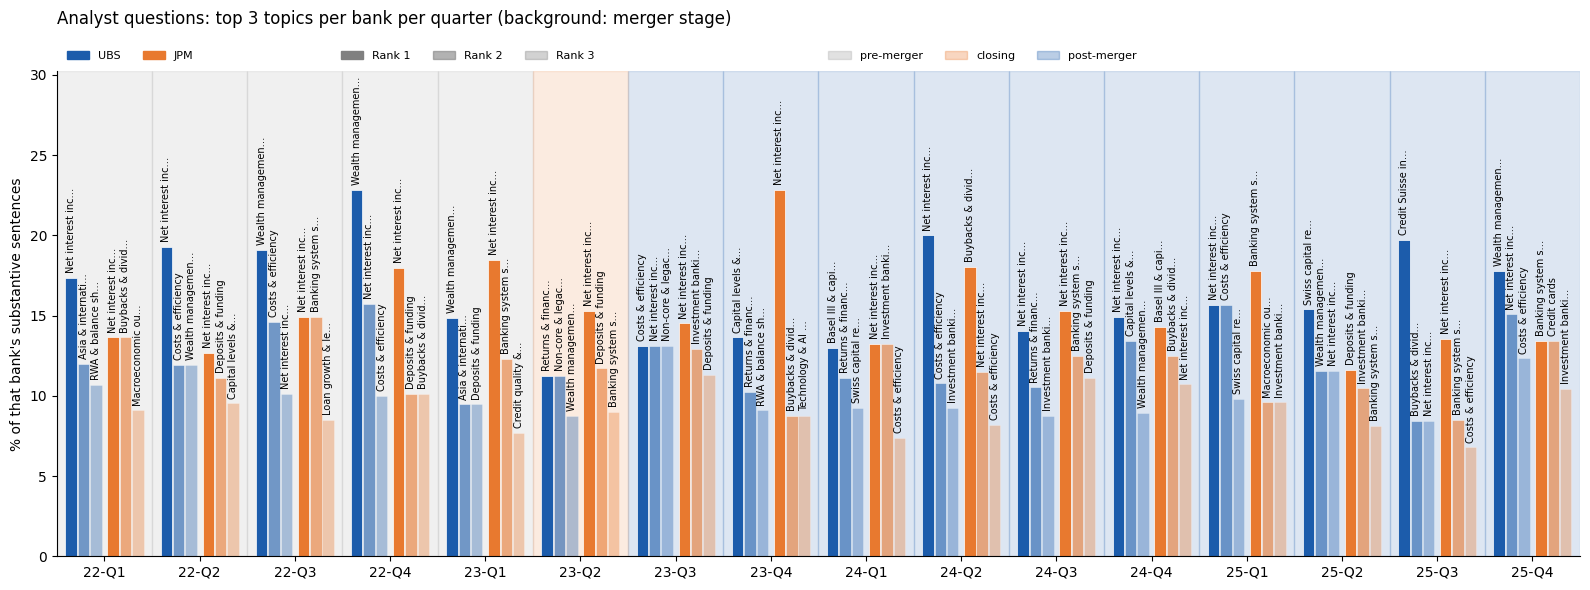

In [22]:
#----------------------------------------------------------------------------
# Top 3 topics per bank per quarter (analyst questions)
# Every analyst sentence has one topic. For each bank and quarter, the three topics with the largest share of
# sentences are drawn.
# JPM 2023-Q2 pools two calls here: the 1 May First Republic call and the 14 July earnings call.
# The merger section below keeps them apart.
#----------------------------------------------------------------------------
STAGE_COLOR = {"pre-merger": "#9e9e9e", "closing": "#e8792f", "post-merger": "#1c5cab"}

def is_real_topic(label):
    return pd.notna(label) and label not in NON_SUBSTANTIVE

def quarter_axis(ax):
    ax.set_xticks(range(len(QUARTERS)), [q[2:] for q in QUARTERS], rotation=45)
    ax.set_xlim(-0.4, len(QUARTERS) - 0.2)

def mark_breaks(ax, banks=BANKS):
    for b in banks:
        if BREAKS[b][0] in QUARTERS:
            ax.axvline(QUARTERS.index(BREAKS[b][0]), color=BANK_COLOR[b], lw=1, ls=":", zorder=0)

def get_top_n(df, topic_col, bank, period, n=3, period_col="quarter"):
    subset = df[(df["bank"] == bank) & (df[period_col] == period) & df[topic_col].apply(is_real_topic)]
    if subset.empty:
        return [("", 0)] * n
    vc = subset[topic_col].value_counts()
    return [(vc.index[i], 100 * vc.iloc[i] / len(subset)) if i < len(vc) else ("", 0) for i in range(n)]

def plot_top3_grouped_bars(df, topic_col, periods, title, period_col="quarter",
                           figsize=(16, 6), label_len=18, label_size=7):
    bank_offset = {"UBS": -0.22, "JPM": 0.22}
    rank_offsets = [-0.13, 0, 0.13]
    rank_alpha = [1.0, 0.6, 0.35]
    bar_width = 0.12
    records = [{"i": i, "bank": bank, "rank": rank, "name": name, "share": share}
               for i, p in enumerate(periods) for bank in BANKS
               for rank, (name, share) in enumerate(get_top_n(df, topic_col, bank, p, 3, period_col))]
    max_share = max(r["share"] for r in records) or 1.0
    longest = min(label_len, max((len(r["name"]) for r in records), default=1))
    label_frac = longest * label_size * 0.55 / 72 / (figsize[1] * 0.75)       # room the rotated names need
    top = max_share / max(0.3, 0.97 - label_frac)

    fig, ax = plt.subplots(figsize=figsize)
    for i, p in enumerate(periods):
        ax.axvspan(i - 0.5, i + 0.5, color=STAGE_COLOR[stage_for_quarter(p[:7])], alpha=0.15, zorder=0)
    for r in records:
        x = r["i"] + bank_offset[r["bank"]] + rank_offsets[r["rank"]]
        ax.bar(x, r["share"], width=bar_width, color=BANK_COLOR[r["bank"]], alpha=rank_alpha[r["rank"]],
               edgecolor="white", linewidth=0.5, zorder=2)
        if r["name"]:
            label = r["name"] if len(r["name"]) <= label_len else r["name"][:label_len - 2] + "…"
            ax.text(x, r["share"] + top * 0.01, label, rotation=90, ha="center", va="bottom", fontsize=label_size)
    ax.set_xticks(range(len(periods)), [p[2:].replace(" event", "\nevent") for p in periods])
    ax.set_xlim(-0.5, len(periods) - 0.5)
    ax.set_ylabel("% of that bank's substantive sentences")
    ax.set_ylim(0, top)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.set_title(title, loc="left", pad=34)
    bank_h = [plt.Rectangle((0, 0), 1, 1, color=BANK_COLOR[b], label=b) for b in BANKS]
    rank_h = [plt.Rectangle((0, 0), 1, 1, color="gray", alpha=a, label=f"Rank {i + 1}") for i, a in enumerate(rank_alpha)]
    stage_h = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.3, label=s) for s, c in STAGE_COLOR.items()]
    l1 = ax.legend(handles=bank_h, loc="lower left", bbox_to_anchor=(0.0, 1.0), ncol=2, fontsize=8, frameon=False)
    ax.add_artist(l1)
    l2 = ax.legend(handles=rank_h, loc="lower left", bbox_to_anchor=(0.18, 1.0), ncol=3, fontsize=8, frameon=False)
    ax.add_artist(l2)
    ax.legend(handles=stage_h, loc="lower left", bbox_to_anchor=(0.50, 1.0), ncol=3, fontsize=8, frameon=False)
    plt.tight_layout(); plt.show()

plot_top3_grouped_bars(analyst_df, "topic_label", QUARTERS,
                       "Analyst questions: top 3 topics per bank per quarter (background: merger stage)")

In [23]:
#----------------------------------------------------------------------------
# Which topics recur, and how do the deal topics show up?
#----------------------------------------------------------------------------
def rank_topic_frequency(df, topic_col, rank_position, periods, period_col="quarter"):
    """Which topic sits at a given rank (1, 2 or 3) in each bank and quarter."""
    rows = []
    for bank in BANKS:
        for p in periods:
            name, share = get_top_n(df, topic_col, bank, p, 3, period_col)[rank_position - 1]
            if name:
                rows.append({"bank": bank, "quarter": p, "topic": name, "share": share})
    return pd.DataFrame(rows)

ranks = pd.concat([rank_topic_frequency(analyst_df, "topic_label", r, QUARTERS).assign(rank=r) for r in (1, 2, 3)])
recur = (ranks.groupby(["bank", "topic"])
         .agg(quarters_in_top3=("quarter", "nunique"),
              quarters_ranked_first=("rank", lambda s: int((s == 1).sum())),
              avg_share_pct=("share", "mean"))
         .round(1).reset_index()
         .sort_values(["bank", "quarters_in_top3", "quarters_ranked_first"], ascending=[True, False, False]))
print(f"=== Topics by number of quarters in the top 3 (max {len(QUARTERS)}) ===")
print(recur.groupby("bank").head(8).to_string(index=False))
for bank in BANKS:
    top = recur[recur["bank"] == bank].head(3)
    print(f"{bank}: the topics that recur most are " +
          ", ".join(f"{r.topic} ({r.quarters_in_top3} of {len(QUARTERS)} quarters)" for r in top.itertuples()) + ".")

# The deal topics: how often they reach the top 3, and how their share moves around the deals
DEAL_TOPICS = ["Credit Suisse integration", "Non-core & legacy run-down", "First Republic acquisition"]
real = analyst_df[analyst_df["topic_label"].apply(is_real_topic)]
rows = []
for bank in BANKS:
    g = real[real["bank"] == bank]
    for topic in DEAL_TOPICS:
        hit = g["topic_label"] == topic
        if hit.sum() == 0:
            continue
        by_q = hit.groupby(g["quarter"]).mean().mul(100).reindex(QUARTERS)
        rows.append({"bank": bank, "topic": topic, "sentences": int(hit.sum()),
                     "quarters_in_top3": int(ranks[(ranks["bank"] == bank) & (ranks["topic"] == topic)]["quarter"].nunique()),
                     "share_before_%": round(100 * hit[g["era"] == "pre"].mean(), 1),
                     "share_after_%": round(100 * hit[g["era"] == "post"].mean(), 1),
                     "peak_quarter": by_q.idxmax(), "peak_share_%": round(by_q.max(), 1)})
print("\n=== Deal topics (share = % of the bank's substantive analyst sentences; before = up to 2023-Q1, after = 2023-Q2 on) ===")
print(pd.DataFrame(rows).to_string(index=False) if rows else "(no sentences carry a deal topic label)")

=== Topics by number of quarters in the top 3 (max 16) ===
bank                                      topic  quarters_in_top3  quarters_ranked_first  avg_share_pct
 JPM     Net interest income & rate sensitivity                13                     11           15.0
 JPM                   Banking system stability                 8                      2           12.1
 JPM                         Deposits & funding                 6                      1           11.2
 JPM                       Buybacks & dividends                 5                      1           12.6
 JPM               Investment banking & markets                 5                      0           11.3
 JPM                         Costs & efficiency                 3                      0            7.4
 JPM                      Macroeconomic outlook                 2                      0            9.3
 JPM             Basel III & capital regulation                 1                      1           14.3
 UBS 

# Merger period

Paired Q&A exchanges in the merger period:
bank           JPM  UBS
period                 
2023-Q1         26   16
2023-Q2         31   16
2023-Q2 event   21    0
2023-Q3         21   12
2023-Q4         19   18

Analyst sentences in the window: 835

=== Analyst questions: top 3 topics over the whole window ===
bank  rank                                  topic  sentences  share_%
 UBS     1             Non-core & legacy run-down         27      8.9
 UBS     2                     Costs & efficiency         26      8.6
 UBS     3            Returns & financial targets         25      8.3
 JPM     1 Net interest income & rate sensitivity         51     17.3
 JPM     2                     Deposits & funding         27      9.2
 JPM     3               Banking system stability         22      7.5


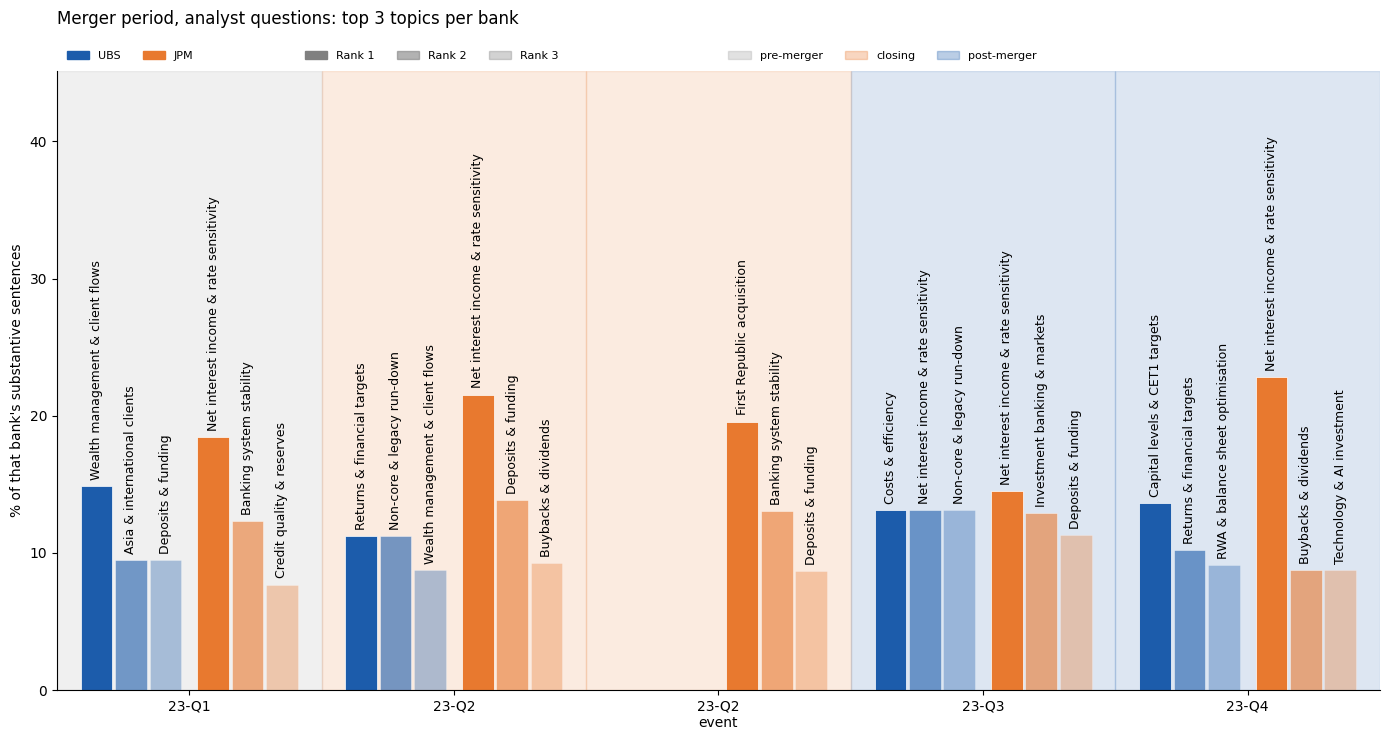

In [24]:
#----------------------------------------------------------------------------
# The merger period: the quarters around both deals closing in 2023-Q2.
# 14 July earnings call. Get separate columns here, so the First Republic call is not blended into the quarter.
#----------------------------------------------------------------------------
MERGER_QUARTERS = ["2023-Q1", "2023-Q2", "2023-Q3", "2023-Q4"]

win_analyst = analyst_df[analyst_df["quarter"].isin(MERGER_QUARTERS)].copy()
win_pairs = qa_pairs[qa_pairs["quarter"].isin(MERGER_QUARTERS)].copy()
WIN_PERIODS = sorted(win_analyst["period"].unique())

print("Paired Q&A exchanges in the merger period:")
print(win_pairs.groupby(["period", "bank"]).size().unstack("bank").fillna(0).astype(int).to_string())
print(f"\nAnalyst sentences in the window: {len(win_analyst):,}")

# The three biggest topics over the whole window
real = win_analyst[win_analyst["topic_label"].apply(is_real_topic)]
rows = []
for bank in BANKS:
    g = real[real["bank"] == bank]
    for rank, (topic, count) in enumerate(g["topic_label"].value_counts().head(3).items(), start=1):
        rows.append({"bank": bank, "rank": rank, "topic": topic, "sentences": count, "share_%": round(100 * count / len(g), 1)})
print("\n=== Analyst questions: top 3 topics over the whole window ===")
print(pd.DataFrame(rows).to_string(index=False))

# The same chart as before, zoomed in on the window (names written out in full)
plot_top3_grouped_bars(win_analyst, "topic_label", WIN_PERIODS,
                       "Merger period, analyst questions: top 3 topics per bank",
                       period_col="period", figsize=(14, 7.5), label_len=40, label_size=9)

In [25]:
#----------------------------------------------------------------------------
# Do the lengths relate to the topics?
# The topic of an exchange is the main topic of the analyst's question.
#----------------------------------------------------------------------------
from scipy.stats import spearmanr

real_x = win_pairs[win_pairs["topic_label_analyst"].apply(is_real_topic)]
print(f"Exchanges in the window with a substantive question topic: {len(real_x)} of {len(win_pairs)}")
for bank in BANKS:
    g = real_x[real_x["bank"] == bank]
    t = (g.groupby("topic_label_analyst")
         .agg(exchanges=("q_words", "size"), question_words=("q_words", "median"), answer_words=("a_words", "median"))
         .query("exchanges >= 3").sort_values("exchanges", ascending=False).head(8))
    print(f"\n=== {bank}: the most common question topics in the window (3+ exchanges): median words ===")
    print(t.round(0).astype(int).to_string())

# Do questions about the deals draw longer answers? (an exchange counts if ANY question sentence has a deal topic)
deal_keys = set(win_analyst.loc[win_analyst["topic_label"].isin(DEAL_TOPICS), "exchange_key"])
win_pairs["asks_about_deal"] = win_pairs["exchange_key"].isin(deal_keys)
t = (win_pairs.groupby(["bank", "asks_about_deal"])
     .agg(exchanges=("q_words", "size"), question_words=("q_words", "median"), answer_words=("a_words", "median")))
print("\n=== Exchanges where the question touches a deal topic vs the rest (window) ===")
print(t.round(0).astype(int).to_string())

# Do longer questions get longer answers?
print()
for bank in BANKS:
    g = win_pairs[win_pairs["bank"] == bank]
    rho, p = spearmanr(g["q_words"], g["a_words"])
    print(f"{bank}: longer questions get longer answers? Spearman rho = {rho:.2f} (p = {p:.3f}, {len(g)} exchanges)")

Exchanges in the window with a substantive question topic: 172 of 180

=== UBS: the most common question topics in the window (3+ exchanges): median words ===
                                  exchanges  question_words  answer_words
topic_label_analyst                                                      
Asia & international clients              7             149           179
Capital levels & CET1 targets             7              96           342
Credit Suisse integration                 5             145           302
Buybacks & dividends                      4             182           378
Basel III & capital regulation            4             115           178
RWA & balance sheet optimisation          4              55           182
Non-core & legacy run-down                4             184           404
Wealth management & client flows          4             168           350

=== JPM: the most common question topics in the window (3+ exchanges): median words ===
            

#Negative Sentences


In [26]:
#----------------------------------------------------------------------------
# Score every analyst and management sentence with FinBERT.
# A sentence counts as "negative" when FinBERT's top label is negative. This measures negative WORDING
#----------------------------------------------------------------------------
import torch
from transformers import pipeline
from tqdm.auto import tqdm

finbert = pipeline("text-classification", model="ProsusAI/finbert", top_k=None,
                   device=0 if torch.cuda.is_available() else -1)

def finbert_scores(texts, chunk=1000):
    """FinBERT's top label and its probability of 'negative', for every text, in order."""
    labels, p_neg = [], []
    for start in tqdm(range(0, len(texts), chunk)):
        batch = finbert(texts[start:start + chunk], batch_size=32, truncation=True, max_length=256)
        for result in batch:
            probs = {r["label"].lower(): r["score"] for r in result}
            labels.append(max(probs, key=probs.get))
            p_neg.append(probs["negative"])
    return labels, p_neg

for frame in (analyst_df, mgmt_df):
    frame["fb_label"], frame["p_neg"] = finbert_scores(frame["sentence"].tolist())
    frame["is_neg"] = frame["fb_label"] == "negative"

# Management answers have no topic model of their own: each answer sentence takes the topic of the question it answers.
mgmt_df["topic_label"] = mgmt_df["exchange_key"].map(qa_pairs.set_index("exchange_key")["topic_label_analyst"])

# Built AFTER scoring, so these copies carry the new columns. Management = Q&A only.
NEG_SIDES = {"Analyst questions": analyst_df,
             "Management answers (Q&A)": mgmt_df[mgmt_df["section"] == "qa"]}

print("% of sentences by FinBERT label:")
for side, frame in NEG_SIDES.items():
    print(f"\n{side}")
    print(frame.groupby("bank")["fb_label"].value_counts(normalize=True).mul(100).round(1).unstack().to_string())

# Spot check: does "negative" mean what we think it means? Read these.
for side, frame in NEG_SIDES.items():
    neg = frame[frame["is_neg"]]
    print(f"\n=== {side}: {len(neg):,} negative sentences of {len(frame):,} ({100 * len(neg) / len(frame):.1f}%) ===")
    for _, r in neg.sample(5, random_state=1).iterrows():
        print(f"  [{r['bank']} {r['quarter']} | {r['topic_label']}] {r['sentence'][:180]}")

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


% of sentences by FinBERT label:

Analyst questions
fb_label  negative  neutral  positive
bank                                 
JPM            9.0     81.1       9.8
UBS            9.1     81.4       9.6

Management answers (Q&A)
fb_label  negative  neutral  positive
bank                                 
JPM           10.8     76.7      12.5
UBS            5.9     72.7      21.3

=== Analyst questions: 284 negative sentences of 3,141 (9.0%) ===
  [UBS 2023-Q4 | Returns & financial targets] You're targeting mid-teens by 2026 and still significantly below what your US peers are doing.
  [UBS 2022-Q3 | Wealth management & client flows] And then, secondly, on capital, clearly the demand for your balance sheet from your wealth clients is much lower than you may have anticipated when you put out plans early in the y
  [UBS 2025-Q1 | Outlier/Unclassified] But nonetheless, it looks a little bit worse than your original guidance.
  [UBS 2022-Q2 | Wealth management & client flows] The – amidst i

In [27]:
#----------------------------------------------------------------------------
# Which topics carry the negative wording? (whole period, 2022-Q1 to 2025-Q4)
#   pct_neg          = % of the topic's sentences that are negative
#   pct_of_bank_neg  = % of the bank's negative sentences that sit in this topic
# A topic is hidden for a bank if it has fewer than MIN_N sentences. Management answers carry the topic of the
# question they answer.
#----------------------------------------------------------------------------
MIN_N = 30

def topic_negativity(frame):
    t = frame[frame["topic_label"].apply(is_real_topic)]
    g = t.groupby(["bank", "topic_label"])["is_neg"].agg(n_sentences="size", n_neg="sum").reset_index()
    g["pct_neg"] = 100 * g["n_neg"] / g["n_sentences"]
    bank_neg = t[t["is_neg"]].groupby("bank").size()
    g["pct_of_bank_neg"] = 100 * g["n_neg"] / g["bank"].map(bank_neg)
    return g[g["n_sentences"] >= MIN_N]

for side, frame in NEG_SIDES.items():
    res = topic_negativity(frame)
    pooled = res.groupby("topic_label")[["n_neg", "n_sentences"]].sum()
    order = (pooled["n_neg"] / pooled["n_sentences"]).sort_values(ascending=False).index
    cols = ["n_sentences", "pct_neg", "pct_of_bank_neg"]
    table = (res.pivot(index="topic_label", columns="bank", values=cols).swaplevel(axis=1)
                .reindex(columns=pd.MultiIndex.from_product([BANKS, cols])).reindex(order).round(1))
    for b in BANKS:
        table[(b, "n_sentences")] = table[(b, "n_sentences")].map(lambda v: "-" if pd.isna(v) else str(int(v)))
    print(f"\n=== {side}: negative sentences by topic (topics with {MIN_N}+ sentences for that bank) ===")
    print(table.to_string(na_rep="-"))


=== Analyst questions: negative sentences by topic (topics with 30+ sentences for that bank) ===
                                                   UBS                                 JPM                        
                                           n_sentences pct_neg pct_of_bank_neg n_sentences pct_neg pct_of_bank_neg
topic_label                                                                                                       
Credit quality & reserves                            -       -               -          53    26.4            11.7
Macroeconomic outlook                                -       -               -          42    23.8             8.3
Net interest income & rate sensitivity             136    16.9            18.3         147    20.4            25.0
Capital levels & CET1 targets                       53    22.6             9.5          31     3.2             0.8
Swiss capital regime & parent bank capital          49    14.3             5.6           -       

Key negative topics (most negative sentences, analysts + management): Net interest income & rate sensitivity, Deposits & funding, Banking system stability, Investment banking & markets, Credit quality & reserves


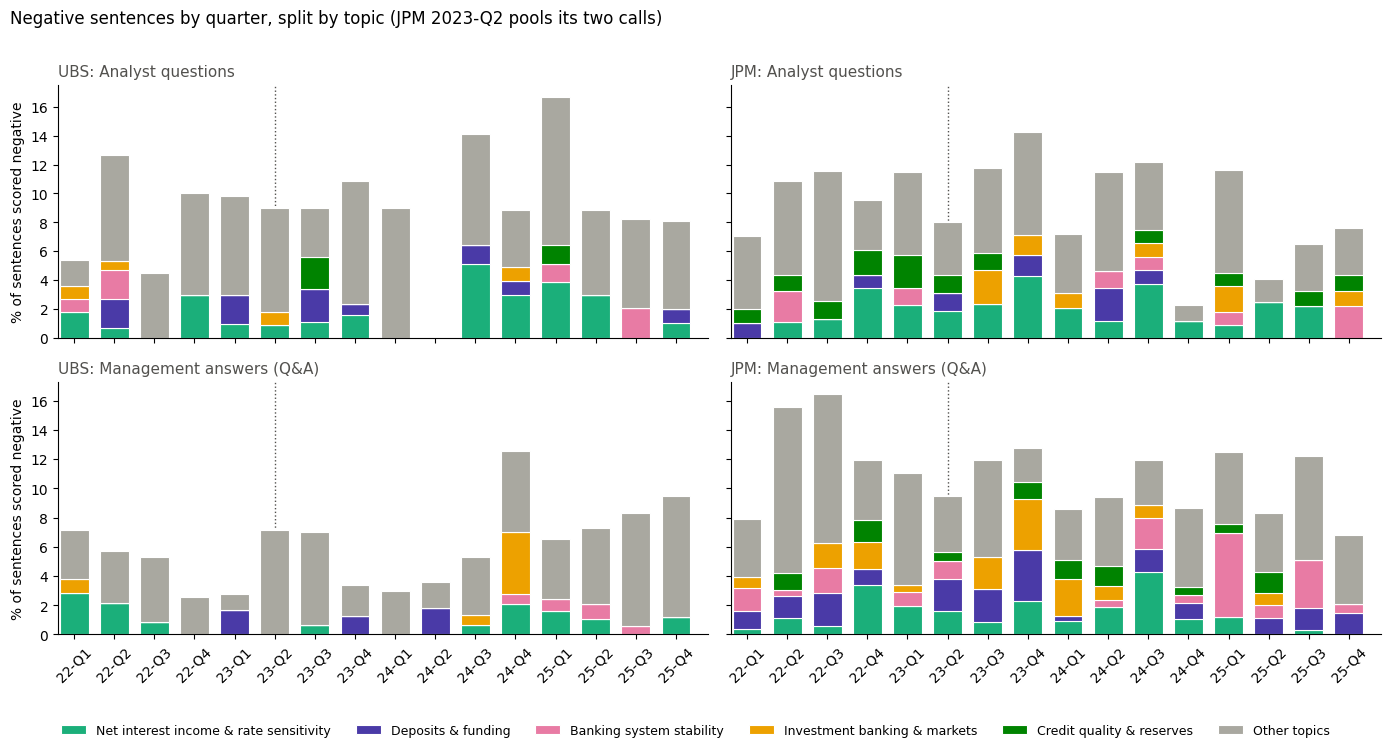

In [28]:
#----------------------------------------------------------------------------
# Negative sentences over time, by topic
# Bar height = % of that bank's sentences in the quarter that FinBERT scores as negative.
# Colour = the topic the negative sentences sit in. The five topics with the most negative sentences (analysts and
# management together) get their own colour; everything else is grey. The dotted line is the quarter both deals closed.
#----------------------------------------------------------------------------
TOPIC_COLOURS = ["#1baf7a", "#4a3aa7", "#e87ba4", "#eda100", "#008300"]   # fixed order, checked for colour-blind separation
OTHER_GREY, INK = "#a9a8a0", "#52514e"

all_neg = pd.concat([f[f["is_neg"] & f["topic_label"].apply(is_real_topic)] for f in NEG_SIDES.values()])
KEY_TOPICS = all_neg["topic_label"].value_counts().head(5).index.tolist()
COLOURS = dict(zip(KEY_TOPICS, TOPIC_COLOURS)); COLOURS["Other topics"] = OTHER_GREY
print("Key negative topics (most negative sentences, analysts + management):", ", ".join(KEY_TOPICS))

def neg_stack(frame, bank):
    f = frame[frame["bank"] == bank]
    total = f.groupby("quarter").size().reindex(QUARTERS)
    out = {t: f[f["is_neg"] & (f["topic_label"] == t)].groupby("quarter").size().reindex(QUARTERS).fillna(0) / total * 100
           for t in KEY_TOPICS}
    all_negative = f[f["is_neg"]].groupby("quarter").size().reindex(QUARTERS).fillna(0) / total * 100
    out["Other topics"] = (all_negative - sum(out.values())).clip(lower=0)
    return pd.DataFrame(out).fillna(0)

fig, axes = plt.subplots(2, 2, figsize=(14, 7.5), sharex=True, sharey="row")
x = np.arange(len(QUARTERS))
for r, (side, frame) in enumerate(NEG_SIDES.items()):
    for c, bank in enumerate(BANKS):
        ax = axes[r][c]; d = neg_stack(frame, bank); bottom = np.zeros(len(QUARTERS))
        for t in d.columns:
            ax.bar(x, d[t].to_numpy(), bottom=bottom, width=0.72, color=COLOURS[t], edgecolor="white", linewidth=0.8, label=t)
            bottom += d[t].to_numpy()
        ax.axvline(QUARTERS.index(DEAL_QUARTER), color=INK, lw=1, ls=":", zorder=0)
        quarter_axis(ax)
        ax.set_title(f"{bank}: {side}", loc="left", fontsize=11, color=INK)
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
        if c == 0:
            ax.set_ylabel("% of sentences scored negative")
handles, names = axes[0][0].get_legend_handles_labels()
fig.legend(handles, names, loc="lower center", ncol=len(names), frameon=False, fontsize=9)
fig.suptitle("Negative sentences by quarter, split by topic (JPM 2023-Q2 pools its two calls)", x=0.01, ha="left")
plt.tight_layout(rect=(0, 0.06, 1, 0.97)); plt.show()

In [29]:
#----------------------------------------------------------------------------
# Slide chart style, Angelo's four windows, and the helpers every chart below uses.
#----------------------------------------------------------------------------
import pathlib, zipfile
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

PPT_DIR = pathlib.Path("ppt_figures")
(PPT_DIR / "tables").mkdir(parents=True, exist_ok=True)

# The same two bank colours as Angelo's notebook, so his slides and ours match.
PPT_COLOR = {"UBS": "#2a78d6", "JPM": "#eb6834"}
P_INK, P_INK2, P_MUTED, P_GRID, P_SPINE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 200,
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "font.size": 11, "axes.titlesize": 14, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.labelcolor": P_INK2, "xtick.color": P_INK2, "ytick.color": P_INK2, "text.color": P_INK,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": P_SPINE,
    "axes.grid": True, "axes.grid.axis": "y", "axes.axisbelow": True,
    "grid.color": P_GRID, "grid.linewidth": 0.7, "lines.linewidth": 2, "legend.frameon": False,
})
SOURCE = "Source: UBS and JPMorgan earnings calls, 2022-Q1 to 2025-Q4, Q&A section."

# Angelo's windows (same for both banks): the year before, the two deal quarters, the first year after, the later quarters.
WINDOWS = {"before": QUARTERS[0:4], "deal": QUARTERS[4:6], "after": QUARTERS[6:10], "later": QUARTERS[10:16]}
WINDOW_OF = {q: w for w, qs in WINDOWS.items() for q in qs}
WINDOW_NAMES = list(WINDOWS)
for frame in (analyst_df, qa_pairs):
    frame["window"] = frame["quarter"].map(WINDOW_OF)

# Each bank's own deal topics, and a join key that is the same as Angelo's (bank | quarter | call type | position | sentence number).
OWN_DEAL = {"UBS": ["Credit Suisse integration", "Non-core & legacy run-down"], "JPM": ["First Republic acquisition"]}

def sentence_key(df):
    return (df["bank"] + "|" + df["quarter"] + "|" + df["call_type"] + "|"
            + df["position_in_call"].astype(int).astype(str) + "|" + df["sentence_number"].astype(int).astype(str))

A_real = analyst_df[analyst_df["topic_label"].apply(is_real_topic)].reset_index(drop=True)   # substantive analyst sentences
A_real["own_deal"] = [t in OWN_DEAL[b] for b, t in zip(A_real["bank"], A_real["topic_label"])]
A_real["key"] = sentence_key(A_real)
deal_keys_all = set(analyst_df.loc[analyst_df["topic_label"].isin(DEAL_TOPICS), "exchange_key"])
qa_pairs["touches_deal"] = qa_pairs["exchange_key"].isin(deal_keys_all)   # any question sentence has a deal topic

# ---- helpers -------------------------------------------------------------------------------------------------------
def unit_codes(unit):
    """Whole numbers 0..k-1, one per exchange (a missing exchange id counts as its own exchange)."""
    codes, _ = pd.factorize(pd.Series(np.asarray(unit, dtype=object)))
    codes = np.asarray(codes).copy()
    bad = codes < 0
    if bad.any():
        codes[bad] = codes.max() + 1 + np.arange(bad.sum())
    return codes

def boot_share(hit, unit, B=1000, seed=42):
    """Share of True in `hit`, with a 95% range from resampling whole exchanges (sentences of one exchange are not independent)."""
    codes = unit_codes(unit); k = codes.max() + 1
    s = np.bincount(codes, weights=np.asarray(hit, dtype=float), minlength=k)
    n = np.bincount(codes, minlength=k).astype(float)
    idx = np.random.default_rng(seed).integers(0, k, size=(B, k))
    boot = s[idx].sum(axis=1) / n[idx].sum(axis=1)
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return s.sum() / n.sum(), lo, hi

def share_table(frame, flag_col, by, groups, unit="exchange_key", B=1000):
    """% of sentences with flag_col True, per bank and group, with the 95% range. One row per bank and group."""
    rows = []
    for bank in BANKS:
        fb = frame[frame["bank"] == bank]
        for g in groups:
            sub = fb[fb[by] == g]
            if len(sub) == 0:
                rows.append({"bank": bank, by: g, "share": np.nan, "lo": np.nan, "hi": np.nan, "n": 0}); continue
            p, lo, hi = boot_share(sub[flag_col], sub[unit], B)
            rows.append({"bank": bank, by: g, "share": 100 * p, "lo": 100 * lo, "hi": 100 * hi, "n": len(sub)})
    return pd.DataFrame(rows)

def boot_median(values, B=1000, seed=42):
    v = np.asarray(values, dtype=float)
    if len(v) < 2:
        return (float(v[0]) if len(v) else np.nan), np.nan, np.nan
    m = np.median(np.random.default_rng(seed).choice(v, size=(B, len(v))), axis=1)
    return float(np.median(v)), *np.percentile(m, [2.5, 97.5])

X = np.arange(len(QUARTERS)); QLABELS = [q[2:] for q in QUARTERS]
EVENT_X = QUARTERS.index("2023-Q2")                 # JPM's 1 May 2023 First Republic call sits in this quarter

def time_axis(ax, title, pad=30):
    """Quarter axis, deal quarters shaded, the four windows named along the top."""
    ax.set_xticks(X, QLABELS, rotation=45, fontsize=9)
    ax.set_xlim(-0.5, len(QUARTERS) - 0.5)
    deal = [QUARTERS.index(q) for q in WINDOWS["deal"]]
    ax.axvspan(deal[0] - 0.5, deal[-1] + 0.5, color="#efeee8", lw=0, zorder=0)
    for w, qs in WINDOWS.items():
        mid = (QUARTERS.index(qs[0]) + QUARTERS.index(qs[-1])) / 2
        ax.text(mid, 1.01, w, transform=ax.get_xaxis_transform(), ha="center", va="bottom", fontsize=8, color=P_MUTED)
    ax.set_title(title, loc="left", pad=pad)

FIGURES = {}                                         # file name -> what the chart shows (listed at the end)
def save_fig(fig, name, what, table=None, note=""):
    """Save the chart (PNG, 200 dpi) and its numbers (CSV); put a source line under it."""
    fig.text(0.005, -0.02, (SOURCE + " " + note).strip(), fontsize=8, color=P_MUTED, ha="left", va="top", wrap=True)
    fig.savefig(PPT_DIR / f"{name}.png", dpi=200, bbox_inches="tight")
    if table is not None:
        table.to_csv(PPT_DIR / "tables" / f"{name}.csv")
    FIGURES[name] = what
    plt.show()

# ---- Angelo's output files (optional). Copy them into ANGELO_DIR; without them the cross-check cells skip themselves.
ANGELO_DIR = FOLDER
def angelo_file(name, cols):
    p = pathlib.Path(ANGELO_DIR) / name
    return pd.read_csv(p, usecols=cols) if p.exists() else None

print(f"Windows: " + "; ".join(f"{w} = {qs[0]} to {qs[-1]}" for w, qs in WINDOWS.items()))
print(f"Substantive analyst sentences: {len(A_real):,}  |  Q&A exchanges: {len(qa_pairs):,}")
print("Angelo's files found:", [n for n in ("themes_sentence.csv", "topics_sentence.csv")
                                  if (pathlib.Path(ANGELO_DIR) / n).exists()] or "none (the cross-check cells will skip)")

Windows: before = 2022-Q1 to 2022-Q4; deal = 2023-Q1 to 2023-Q2; after = 2023-Q3 to 2024-Q2; later = 2024-Q3 to 2025-Q4
Substantive analyst sentences: 2,212  |  Q&A exchanges: 651
Angelo's files found: none (the cross-check cells will skip)


=== F1: % of substantive analyst sentences on the bank's own deal topics ===
bank                  JPM   UBS
quarter                        
2022-Q1               0.0   0.0
2022-Q2               1.6   1.8
2022-Q3               0.0   2.2
2022-Q4               1.1   2.9
2023-Q1               0.0   8.1
2023-Q2               8.1  20.0
2023-Q3               1.6  16.4
2023-Q4               5.3  14.8
2024-Q1               1.5  13.0
2024-Q2               0.0   9.2
2024-Q3               0.0   3.5
2024-Q4               0.0   6.0
2025-Q1               1.4   0.0
2025-Q2               0.0   0.0
2025-Q3               0.0  22.5
2025-Q4               0.0   2.7
JPM event call alone  NaN  19.6


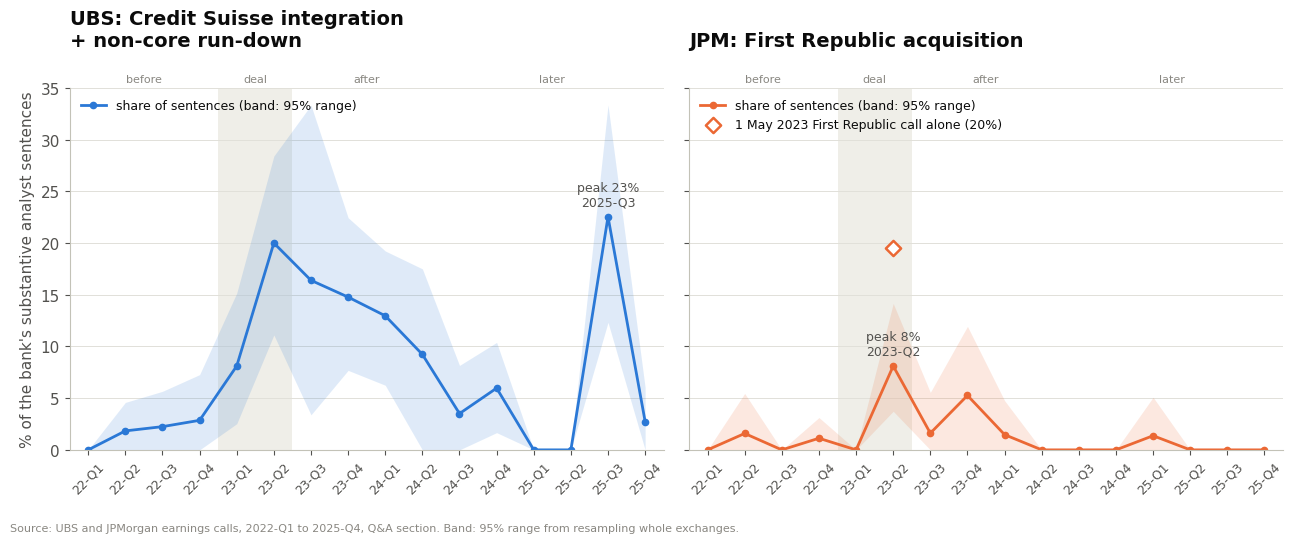

In [30]:
#----------------------------------------------------------------------------
# F1  Attention to each bank's own deal, quarter by quarter.
#----------------------------------------------------------------------------
f1 = share_table(A_real, "own_deal", by="quarter", groups=QUARTERS)
ev = A_real[A_real["call_type"] == "event"]
ev_p, ev_lo, ev_hi = boot_share(ev["own_deal"], ev["exchange_key"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
LABEL = {"UBS": "UBS: Credit Suisse integration\n+ non-core run-down", "JPM": "JPM: First Republic acquisition"}
for ax, b in zip(axes, BANKS):
    s = f1[f1["bank"] == b].set_index("quarter").reindex(QUARTERS)
    ax.fill_between(X, s["lo"], s["hi"], color=PPT_COLOR[b], alpha=0.15, lw=0)
    ax.plot(X, s["share"], color=PPT_COLOR[b], marker="o", ms=4.5, label="share of sentences (band: 95% range)")
    top = s["share"].idxmax()
    ax.annotate(f"peak {s['share'].max():.0f}%\n{top}", (QUARTERS.index(top), s["share"].max()), xytext=(0, 8),
                textcoords="offset points", ha="center", fontsize=9, color=P_INK2)
    time_axis(ax, LABEL[b], pad=30)
    ax.title.set_fontsize(12)
axes[1].scatter([EVENT_X], [100 * ev_p], marker="D", s=60, facecolors="white", edgecolors=PPT_COLOR["JPM"], linewidths=1.8,
                zorder=5, label=f"1 May 2023 First Republic call alone ({100 * ev_p:.0f}%)")
axes[0].set_ylabel("% of the bank's substantive analyst sentences"); axes[0].set_ylim(bottom=0)
for ax in axes:
    ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
tbl = f1.pivot(index="quarter", columns="bank", values="share").reindex(QUARTERS).round(1)
tbl.loc["JPM event call alone"] = [np.nan, round(100 * ev_p, 1)]
print("=== F1: % of substantive analyst sentences on the bank's own deal topics ===")
print(tbl.to_string())
save_fig(fig, "F1_deal_attention", "Deal talk in analyst questions by quarter, with 95% ranges", f1.round(2),
         "Band: 95% range from resampling whole exchanges.")

=== F3: change in share of analyst sentences, 2022 to 2023-Q3/2024-Q2 (percentage points) ===
                                     topic  UBS before %  UBS after %  JPM before %  JPM after %  UBS change  JPM change  gap (UBS - JPM)     lo    hi  range excludes 0
          Wealth management & client flows         15.45         4.10          0.38         1.21      -11.35        0.83           -12.18 -18.35 -5.87              True
              Asia & international clients          6.71         3.73          1.89         2.02       -2.97        0.13            -3.10  -7.37  1.69             False
                      Buybacks & dividends          3.79         4.10          7.92         8.87        0.31        0.95            -0.63  -8.69  6.85             False
            Basel III & capital regulation          2.33         6.72          2.26         4.03        4.38        1.77             2.62  -2.13  7.62             False
                 Credit Suisse integration          1.46     

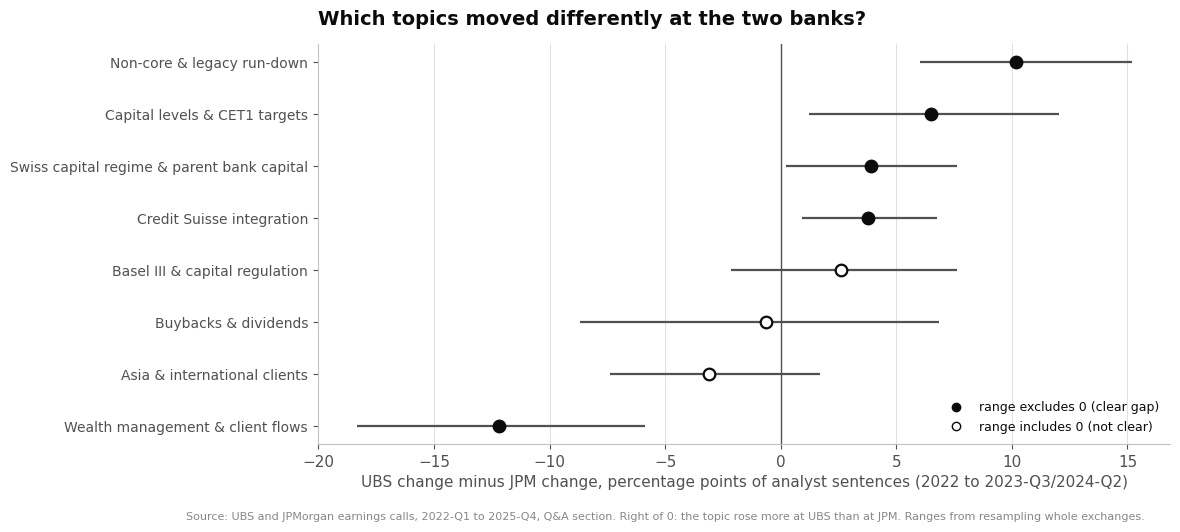

In [32]:
#----------------------------------------------------------------------------
# F3  Did the two banks change differently? (UBS change minus JPM change, per topic)
#----------------------------------------------------------------------------
DID_TOPICS = ["Credit Suisse integration", "Non-core & legacy run-down", "Capital levels & CET1 targets",
              "Basel III & capital regulation", "Swiss capital regime & parent bank capital",
              "Wealth management & client flows", "Asia & international clients", "Buybacks & dividends"]
DID_TOPICS = [t for t in DID_TOPICS if t in set(A_real["topic_label"])]

def cell_counts(sub, topics):
    codes = unit_codes(sub["exchange_key"])
    H = np.zeros((codes.max() + 1, len(topics)))
    np.add.at(H, codes, np.column_stack([(sub["topic_label"] == t).to_numpy(float) for t in topics]))
    return H, np.bincount(codes).astype(float)

B_DID = 1000
rng = np.random.default_rng(42)
point, boot = {}, {}
for b in BANKS:
    for w in ("before", "after"):
        H, N = cell_counts(A_real[(A_real["bank"] == b) & (A_real["window"] == w)], DID_TOPICS)
        point[b, w] = 100 * H.sum(0) / N.sum()
        idx = rng.integers(0, len(N), size=(B_DID, len(N)))
        boot[b, w] = 100 * H[idx].sum(1) / N[idx].sum(1)[:, None]
chg = {b: point[b, "after"] - point[b, "before"] for b in BANKS}
gap = chg["UBS"] - chg["JPM"]
gap_boot = (boot["UBS", "after"] - boot["UBS", "before"]) - (boot["JPM", "after"] - boot["JPM", "before"])
lo, hi = np.percentile(gap_boot, [2.5, 97.5], axis=0)
f3 = pd.DataFrame({"topic": DID_TOPICS, "UBS before %": point["UBS", "before"], "UBS after %": point["UBS", "after"],
                   "JPM before %": point["JPM", "before"], "JPM after %": point["JPM", "after"],
                   "UBS change": chg["UBS"], "JPM change": chg["JPM"], "gap (UBS - JPM)": gap, "lo": lo, "hi": hi})
f3["range excludes 0"] = (f3["lo"] > 0) | (f3["hi"] < 0)
f3 = f3.sort_values("gap (UBS - JPM)").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
y = np.arange(len(f3))
ax.axvline(0, color=P_INK2, lw=1, zorder=1)
for i, r in f3.iterrows():
    ax.plot([r["lo"], r["hi"]], [i, i], color=P_INK2, lw=1.6, solid_capstyle="butt", zorder=2)
    ax.scatter([r["gap (UBS - JPM)"]], [i], s=70, zorder=3, edgecolors=P_INK, linewidths=1.6,
               facecolors=P_INK if r["range excludes 0"] else "white")
ax.set_yticks(y, f3["topic"], fontsize=10)
ax.set_xlabel("UBS change minus JPM change, percentage points of analyst sentences (2022 to 2023-Q3/2024-Q2)")
ax.set_title("Which topics moved differently at the two banks?", loc="left", pad=14)
ax.legend(handles=[Line2D([], [], marker="o", ls="", mfc=P_INK, mec=P_INK, label="range excludes 0 (clear gap)"),
                   Line2D([], [], marker="o", ls="", mfc="white", mec=P_INK, label="range includes 0 (not clear)")],
          loc="lower right", fontsize=9)
print("=== F3: change in share of analyst sentences, 2022 to 2023-Q3/2024-Q2 (percentage points) ===")
print(f3.round(2).to_string(index=False))
save_fig(fig, "F3_ubs_vs_jpm_gap", "UBS change minus JPM change per topic, with 95% ranges", f3.round(3),
         "Right of 0: the topic rose more at UBS than at JPM. Ranges from resampling whole exchanges.")

=== F4: median words per exchange, merger quarters ===
bank   exchange              part  median_words    lo    hi  exchanges
 UBS deal topic  Analyst question         160.0 146.0 184.0         28
 UBS deal topic Management answer         358.0 314.0 412.0         28
 UBS      other  Analyst question         101.0  68.0 127.0         34
 UBS      other Management answer         190.0 142.0 300.0         34
 JPM deal topic  Analyst question          59.0  44.0  71.0         16
 JPM deal topic Management answer         168.0  72.0 226.0         16
 JPM      other  Analyst question          64.0  59.0  76.0        102
 JPM      other Management answer         144.0 126.0 168.0        102


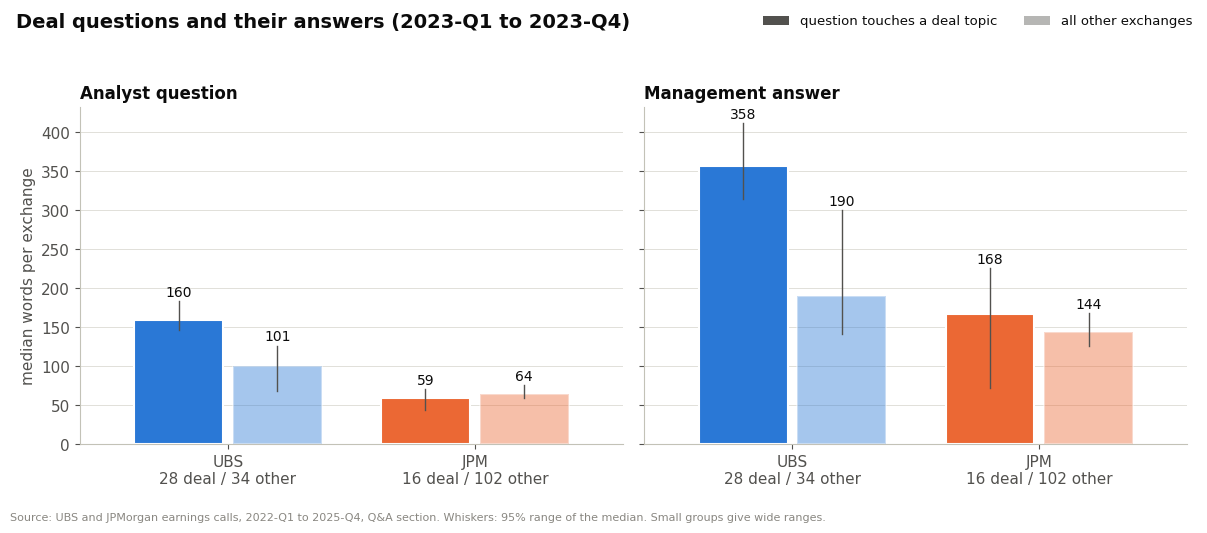

In [33]:
#----------------------------------------------------------------------------
# F4  How questions and answers are expressed: length.
# Median words per exchange in the four merger quarters, for exchanges where the question touches a deal topic
# vs all other exchanges.
#----------------------------------------------------------------------------
win = qa_pairs[qa_pairs["quarter"].isin(MERGER_QUARTERS)]
rows = []
for b in BANKS:
    for deal in (True, False):
        g = win[(win["bank"] == b) & (win["touches_deal"] == deal)]
        for col, what in (("q_words", "Analyst question"), ("a_words", "Management answer")):
            med, lo, hi = boot_median(g[col])
            rows.append({"bank": b, "exchange": "deal topic" if deal else "other", "part": what,
                         "median_words": med, "lo": lo, "hi": hi, "exchanges": len(g)})
f4 = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, what in zip(axes, ("Analyst question", "Management answer")):
    for j, b in enumerate(BANKS):
        for k, kind in enumerate(("deal topic", "other")):
            r = f4[(f4["bank"] == b) & (f4["exchange"] == kind) & (f4["part"] == what)].iloc[0]
            x_ = j + (k - 0.5) * 0.4
            ax.bar(x_, r["median_words"], width=0.36, color=PPT_COLOR[b], alpha=1.0 if kind == "deal topic" else 0.42,
                   edgecolor="white", linewidth=1.5, zorder=2)
            if pd.notna(r["lo"]):
                ax.plot([x_, x_], [r["lo"], r["hi"]], color=P_INK2, lw=1, zorder=3)
            top = r["hi"] if pd.notna(r["hi"]) else r["median_words"]
            ax.text(x_, top + 6, f"{r['median_words']:.0f}", ha="center", fontsize=10, color=P_INK)
    ns_ = {b: (int(((win["bank"] == b) & win["touches_deal"]).sum()), int(((win["bank"] == b) & ~win["touches_deal"]).sum())) for b in BANKS}
    ax.set_xticks(range(2), [f"{b}\n{ns_[b][0]} deal / {ns_[b][1]} other" for b in BANKS])
    ax.set_xlim(-0.6, 1.6)
    ax.set_title(what, loc="left", fontsize=12)
axes[0].set_ylabel("median words per exchange")
fig.legend(handles=[Patch(facecolor=P_INK2, label="question touches a deal topic"),
                    Patch(facecolor=P_INK2, alpha=0.42, label="all other exchanges")],
           loc="upper right", bbox_to_anchor=(1, 1.0), ncol=2, fontsize=9.5)
fig.suptitle(f"Deal questions and their answers ({MERGER_QUARTERS[0]} to {MERGER_QUARTERS[-1]})", x=0.01, ha="left",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.94))
print("=== F4: median words per exchange, merger quarters ===")
print(f4.round(0).to_string(index=False))
save_fig(fig, "F4_question_answer_length", "Median question and answer length, deal-topic exchanges vs the rest, merger quarters",
         f4.round(1), "Whiskers: 95% range of the median. Small groups give wide ranges.")